# NCA Parent ML — Annual IA45 z-score normalization

This notebook recreates the current supervised parent-cluster workflow using **year-relative IA45 coordinates** instead of raw IA45 values.

The scientific test is intentionally simple:

\[
\text{raw IA45} \rightarrow \text{vegetation parent}
\]

versus

\[
\text{annual z-scored IA45} \rightarrow \text{vegetation parent}.
\]

No climate covariates, temporal priors, label propagation, or new classifier tuning are introduced here. The purpose is to isolate whether annual displacement of the optical feature distributions is responsible for part of the poor cross-year transfer.

## Reference population

Annual normalization parameters are estimated from the fixed optical sample written by:

`NCA_WriteOpticalSample_IA45.ipynb`

The default reference is the **persistent-valid S500 sample**, so exactly the same optical locations contribute to every annual distribution.

Because the sampling design is approximately equal-per-tile rather than proportional to valid landscape area, annual means and SDs are estimated using tile-level population weights.

For feature \(j\) in year \(t\):

\[
\mu_{jt}
=
\frac{\sum_i w_i x_{ijt}}
{\sum_i w_i}
\]

and

\[
\sigma_{jt}
=
\sqrt{
\frac{\sum_i w_i(x_{ijt}-\mu_{jt})^2}
{\sum_i w_i}
}.
\]

Then every observation from year \(t\) is transformed with:

\[
z_{ijt}
=
\frac{x_{ijt}-\mu_{jt}}
{\sigma_{jt}}.
\]

The same year-specific parameters are used for:

- field vegetation observations;
- grouped OOF / leave-one-year-out validation;
- every raster pixel during mapping.

The full z-scored rasters are **not written to disk**. Raster blocks are transformed in memory immediately before prediction.


In [1]:
from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)


# =============================================================================
# PATHS
# =============================================================================

OPTICAL_SAMPLE_DIR = Path(
    r"C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45"
)

VEG_TRAINING_CSV = Path(
    r"A:\NCA_DATA\Validation\Supervised_State_Classification"
    r"\FieldVeg_K2_IA45_Training.csv"
)

HARMONIC_ROOT = Path(
    r"A:\NCA_DATA\S2_Harmonics"
)

KEEP_MASK = Path(
    r"C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif"
)

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# ANALYSIS SETTINGS
# =============================================================================

YEARS_TO_MAP = list(
    range(
        2016,
        2026,
    )
)

VEG_YEARS = [
    2016,
    2018,
    2025,
]

SAMPLE_TIERS = [
    100,
    250,
    500,
]

REFERENCE_TIER = 500

EXPECTED_D = 45

VEG_PARENT_CODES = list(
    range(
        1,
        9,
    )
)

VEG_CLASSES = [
    f"VEG::{i}"
    for i in VEG_PARENT_CODES
]

CLASS_TO_CODE = {
    f"VEG::{i}": i
    for i in VEG_PARENT_CODES
}

CODE_TO_CLASS = {
    code: cls
    for cls, code in CLASS_TO_CODE.items()
}

RANDOM_STATE = 42
N_SPLITS = 5
COMPRESS = "DEFLATE"

MODEL_FOR_MAPPING = "random_forest"

# Keep False for the cleanest paired experiment against the original
# 479-row supervised baseline. Set True later if you want the classifier
# trained strictly inside the v2 mapping domain.
FILTER_TRAINING_TO_MASK = False

# Mapping can take hours; diagnostics and validation run before this cell.
RUN_ALL_YEAR_MAPPING = True

print("Optical sample:", OPTICAL_SAMPLE_DIR)
print("Vegetation training:", VEG_TRAINING_CSV)
print("Mask:", KEEP_MASK)
print("Output:", OUTPUT_DIR)
print("Reference tier:", f"S{REFERENCE_TIER}")
print("Filter training to mask:", FILTER_TRAINING_TO_MASK)


Optical sample: C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45
Vegetation training: A:\NCA_DATA\Validation\Supervised_State_Classification\FieldVeg_K2_IA45_Training.csv
Mask: C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif
Output: C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45
Reference tier: S500
Filter training to mask: False


## 1. Load static-sample metadata and temporal support

The annual normalization reference uses only points with complete IA45 support from 2016–2025.


In [2]:
# =============================================================================
# 1. STATIC SAMPLE METADATA
# =============================================================================

TILE_MANIFEST = (
    OPTICAL_SAMPLE_DIR
    / "static_optical_tile_manifest.csv"
)

TEMPORAL_COVERAGE = (
    OPTICAL_SAMPLE_DIR
    / "static_optical_sample_temporal_coverage.csv"
)

for path in [
    TILE_MANIFEST,
    TEMPORAL_COVERAGE,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required optical-sample output not found:\n{path}"
        )

tiles = pd.read_csv(
    TILE_MANIFEST
)

sample_temporal = pd.read_csv(
    TEMPORAL_COVERAGE
)

sample_temporal[
    "persistent_valid"
] = (
    sample_temporal[
        "persistent_valid"
    ]
    .astype(str)
    .str.lower()
    .map(
        {
            "true": True,
            "false": False,
        }
    )
)

if sample_temporal[
    "persistent_valid"
].isna().any():
    raise ValueError(
        "Could not parse persistent_valid in temporal coverage file."
    )

print(
    "Retained tiles:",
    f"{len(tiles):,}"
)

print(
    "Static S500 points:",
    f"{len(sample_temporal):,}"
)

print(
    "Persistent-valid S500 points:",
    f"{sample_temporal['persistent_valid'].sum():,}"
)

display(
    sample_temporal[
        [
            "point_id",
            "tile_id",
            "sample_rank",
            "persistent_valid",
            "n_valid_years",
        ]
    ].head()
)


Retained tiles: 488
Static S500 points: 242,696
Persistent-valid S500 points: 240,567


,point_id,tile_id,sample_rank,persistent_valid,n_valid_years
0,P0000001,T0001,1,True,10
1,P0000002,T0001,2,True,10
2,P0000003,T0001,3,True,10
3,P0000004,T0001,4,True,10
4,P0000005,T0001,5,True,10


## 2. Identify the 45 IA features from the annual static-sample tables


In [3]:
# =============================================================================
# 2. IA45 FEATURE NAMES
# =============================================================================

def annual_sample_path(
    year,
):
    return (
        OPTICAL_SAMPLE_DIR
        / f"static_optical_IA45_{year}.csv.gz"
    )


ANNUAL_METADATA_COLS = {
    "point_id",
    "Year",
    "tile_id",
    "sample_rank",
    "mask_row",
    "mask_col",
    "Easting",
    "Northing",
    "in_s100",
    "in_s250",
    "in_s500",
    "valid_ia45",
}


first_annual_path = annual_sample_path(
    YEARS_TO_MAP[0]
)

if not first_annual_path.exists():
    raise FileNotFoundError(
        f"Annual optical sample not found:\n{first_annual_path}"
    )

first_header = pd.read_csv(
    first_annual_path,
    compression="gzip",
    nrows=0,
)

SAMPLE_IA_COLS = [
    c
    for c in first_header.columns
    if c not in ANNUAL_METADATA_COLS
]

if len(
    SAMPLE_IA_COLS
) != EXPECTED_D:
    raise ValueError(
        f"Expected {EXPECTED_D} optical feature columns; "
        f"found {len(SAMPLE_IA_COLS)}."
    )

print(
    "IA45 feature count:",
    len(
        SAMPLE_IA_COLS
    )
)

print(
    "\nFirst 10 features:"
)

print(
    SAMPLE_IA_COLS[
        :10
    ]
)


IA45 feature count: 45

First 10 features:
['constant_B2', 'constant_B3', 'constant_B4', 'constant_B5', 'constant_B6', 'constant_B7', 'constant_B8', 'constant_B8A', 'constant_B11', 'constant_B12']


## 3. Compute weighted annual mean and SD at S100 / S250 / S500

The three sampling tiers are retained as a convergence diagnostic.

For each tier:

- keep only `persistent_valid` static locations;
- within each tile, let \(n_h\) be the number of retained sample points;
- assign each point the expansion weight
  \[
  w_h=N_h/n_h
  \]
  where \(N_h\) is the number of valid-mask pixels in that tile;
- calculate weighted annual mean and weighted population SD for each IA45 feature.

The S500 parameters are used for the ML experiment by default.


In [4]:
# =============================================================================
# 3. WEIGHTED ANNUAL NORMALIZATION PARAMETERS
# =============================================================================

def weighted_mean_sd(
    x,
    w,
):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    w = np.asarray(
        w,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(
            x
        )
        & np.isfinite(
            w
        )
        & (
            w > 0
        )
    )

    x = x[
        valid
    ]

    w = w[
        valid
    ]

    if len(
        x
    ) == 0:
        return (
            np.nan,
            np.nan,
            0,
            np.nan,
        )

    weight_sum = np.sum(
        w
    )

    mean = np.sum(
        w
        * x
    ) / weight_sum

    variance = np.sum(
        w
        * (
            x
            - mean
        ) ** 2
    ) / weight_sum

    sd = np.sqrt(
        variance
    )

    return (
        float(
            mean
        ),
        float(
            sd
        ),
        int(
            len(
                x
            )
        ),
        float(
            weight_sum
        ),
    )


tile_valid_lookup = (
    tiles[
        [
            "tile_id",
            "n_valid_pixels",
        ]
    ]
    .drop_duplicates()
    .set_index(
        "tile_id"
    )[
        "n_valid_pixels"
    ]
    .to_dict()
)


parameter_rows = []

tier_support_rows = []

for tier in SAMPLE_TIERS:

    tier_points = (
        sample_temporal.loc[
            sample_temporal[
                "persistent_valid"
            ]
            & sample_temporal[
                "sample_rank"
            ].le(
                tier
            ),
            [
                "point_id",
                "tile_id",
                "sample_rank",
            ],
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    per_tile_n = (
        tier_points[
            "tile_id"
        ]
        .value_counts()
        .to_dict()
    )

    missing_tiles = sorted(
        set(
            tiles[
                "tile_id"
            ]
        )
        - set(
            per_tile_n
        )
    )

    if missing_tiles:
        raise RuntimeError(
            f"S{tier}: {len(missing_tiles)} retained tiles have no "
            "persistent-valid optical sample points."
        )

    tier_points[
        "tile_valid_pixels"
    ] = tier_points[
        "tile_id"
    ].map(
        tile_valid_lookup
    )

    tier_points[
        "tier_n_in_tile"
    ] = tier_points[
        "tile_id"
    ].map(
        per_tile_n
    )

    tier_points[
        "population_weight"
    ] = (
        tier_points[
            "tile_valid_pixels"
        ]
        / tier_points[
            "tier_n_in_tile"
        ]
    )

    tier_support_rows.append(
        {
            "sample_tier": f"S{tier}",
            "n_points": len(
                tier_points
            ),
            "n_tiles": tier_points[
                "tile_id"
            ].nunique(),
            "sum_weights": tier_points[
                "population_weight"
            ].sum(),
        }
    )

    for year in YEARS_TO_MAP:

        path = annual_sample_path(
            year
        )

        if not path.exists():
            raise FileNotFoundError(
                f"Missing annual optical sample:\n{path}"
            )

        annual = pd.read_csv(
            path,
            compression="gzip",
            usecols=(
                [
                    "point_id",
                    "valid_ia45",
                ]
                + SAMPLE_IA_COLS
            ),
        )

        annual[
            "valid_ia45"
        ] = (
            annual[
                "valid_ia45"
            ]
            .astype(str)
            .str.lower()
            .map(
                {
                    "true": True,
                    "false": False,
                }
            )
        )

        merged = tier_points.merge(
            annual,
            on="point_id",
            how="left",
            validate="one_to_one",
        )

        if not merged[
            "valid_ia45"
        ].all():
            raise RuntimeError(
                f"S{tier}, {year}: a persistent-valid point is not "
                "valid in the annual extraction."
            )

        weights = merged[
            "population_weight"
        ].to_numpy(
            dtype=np.float64
        )

        for feature in SAMPLE_IA_COLS:

            mean, sd, n, weight_sum = weighted_mean_sd(
                merged[
                    feature
                ].to_numpy(
                    dtype=np.float64
                ),
                weights,
            )

            if not np.isfinite(
                sd
            ) or sd <= 0:
                raise ValueError(
                    f"Non-positive SD for {year}, {feature}, S{tier}: {sd}"
                )

            parameter_rows.append(
                {
                    "sample_tier": f"S{tier}",
                    "tier_n": tier,
                    "Year": year,
                    "feature": feature,
                    "n_sample_points": n,
                    "sum_population_weights": weight_sum,
                    "weighted_mean": mean,
                    "weighted_sd": sd,
                }
            )

        del annual
        del merged


normalization_parameters = pd.DataFrame(
    parameter_rows
)

tier_support = pd.DataFrame(
    tier_support_rows
)

normalization_parameters.to_csv(
    OUTPUT_DIR
    / "annual_IA45_weighted_normalization_parameters_all_tiers.csv",
    index=False,
)

tier_support.to_csv(
    OUTPUT_DIR
    / "annual_IA45_reference_tier_support.csv",
    index=False,
)

display(
    tier_support
)

display(
    normalization_parameters.head(
        10
    )
)


,sample_tier,n_points,n_tiles,sum_weights
0,S100,48398,488,35030021.0
1,S250,120759,488,35030021.0
2,S500,240567,488,35030021.0


,sample_tier,tier_n,Year,feature,n_sample_points,sum_population_weights,weighted_mean,weighted_sd
0,S100,100,2016,constant_B2,48398,35030021.0,0.180769,0.016854
1,S100,100,2016,constant_B3,48398,35030021.0,0.207653,0.021058
2,S100,100,2016,constant_B4,48398,35030021.0,0.236076,0.025391
3,S100,100,2016,constant_B5,48398,35030021.0,0.268829,0.025403
4,S100,100,2016,constant_B6,48398,35030021.0,0.299211,0.027990
5,S100,100,2016,constant_B7,48398,35030021.0,0.312971,0.029844
6,S100,100,2016,constant_B8,48398,35030021.0,0.324795,0.032318
7,S100,100,2016,constant_B8A,48398,35030021.0,0.333007,0.031343
8,S100,100,2016,constant_B11,48398,35030021.0,0.393694,0.029511
9,S100,100,2016,constant_B12,48398,35030021.0,0.330456,0.029102


## 4. Sampling-density convergence QA

This does not choose a tier based on downstream model performance. It only checks how closely S100 and S250 reproduce the S500 annual normalization parameters.

The ML run remains fixed to `REFERENCE_TIER = 500`.


In [5]:
# =============================================================================
# 4. PARAMETER CONVERGENCE ACROSS SAMPLE TIERS
# =============================================================================

wide_mean = normalization_parameters.pivot(
    index=[
        "Year",
        "feature",
    ],
    columns="tier_n",
    values="weighted_mean",
)

wide_sd = normalization_parameters.pivot(
    index=[
        "Year",
        "feature",
    ],
    columns="tier_n",
    values="weighted_sd",
)

convergence = wide_mean.add_prefix(
    "mean_S"
).join(
    wide_sd.add_prefix(
        "sd_S"
    )
).reset_index()

for tier in [
    100,
    250,
]:

    convergence[
        f"abs_mean_diff_S{tier}_vs_S500"
    ] = np.abs(
        convergence[
            f"mean_S{tier}"
        ]
        - convergence[
            "mean_S500"
        ]
    )

    convergence[
        f"abs_sd_diff_S{tier}_vs_S500"
    ] = np.abs(
        convergence[
            f"sd_S{tier}"
        ]
        - convergence[
            "sd_S500"
        ]
    )

    convergence[
        f"mean_diff_in_S500_sd_units_S{tier}"
    ] = (
        convergence[
            f"abs_mean_diff_S{tier}_vs_S500"
        ]
        / convergence[
            "sd_S500"
        ]
    )

    convergence[
        f"relative_sd_diff_S{tier}"
    ] = (
        convergence[
            f"abs_sd_diff_S{tier}_vs_S500"
        ]
        / convergence[
            "sd_S500"
        ]
    )


convergence.to_csv(
    OUTPUT_DIR
    / "annual_IA45_parameter_convergence_S100_S250_S500.csv",
    index=False,
)

summary_rows = []

for tier in [
    100,
    250,
]:

    summary_rows.append(
        {
            "sample_tier": f"S{tier}",
            "median_abs_mean_diff_in_S500_sd_units": convergence[
                f"mean_diff_in_S500_sd_units_S{tier}"
            ].median(),
            "p95_abs_mean_diff_in_S500_sd_units": convergence[
                f"mean_diff_in_S500_sd_units_S{tier}"
            ].quantile(
                0.95
            ),
            "max_abs_mean_diff_in_S500_sd_units": convergence[
                f"mean_diff_in_S500_sd_units_S{tier}"
            ].max(),
            "median_relative_sd_diff": convergence[
                f"relative_sd_diff_S{tier}"
            ].median(),
            "p95_relative_sd_diff": convergence[
                f"relative_sd_diff_S{tier}"
            ].quantile(
                0.95
            ),
            "max_relative_sd_diff": convergence[
                f"relative_sd_diff_S{tier}"
            ].max(),
        }
    )

convergence_summary = pd.DataFrame(
    summary_rows
)

display(
    convergence_summary.round(
        5
    )
)

convergence_summary.to_csv(
    OUTPUT_DIR
    / "annual_IA45_parameter_convergence_summary.csv",
    index=False,
)


,sample_tier,median_abs_mean_diff_in_S500_sd_units,p95_abs_mean_diff_in_S500_sd_units,max_abs_mean_diff_in_S500_sd_units,median_relative_sd_diff,p95_relative_sd_diff,max_relative_sd_diff
0,S100,0.00199,0.00604,0.01298,0.00728,0.04782,0.16573
1,S250,0.00151,0.00394,0.00475,0.00445,0.04128,0.28409


## 5. Select the S500 annual normalization parameters

The resulting table contains one mean and one SD for every year × IA45 feature combination.


In [6]:
# =============================================================================
# 5. REFERENCE PARAMETER TABLE
# =============================================================================

reference_parameters = (
    normalization_parameters.loc[
        normalization_parameters[
            "tier_n"
        ].eq(
            REFERENCE_TIER
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

expected_rows = (
    len(
        YEARS_TO_MAP
    )
    * EXPECTED_D
)

if len(
    reference_parameters
) != expected_rows:

    raise RuntimeError(
        f"Expected {expected_rows} reference rows; "
        f"found {len(reference_parameters)}."
    )

reference_parameters.to_csv(
    OUTPUT_DIR
    / f"annual_IA45_zscore_parameters_S{REFERENCE_TIER}.csv",
    index=False,
)

display(
    reference_parameters.head(
        10
    )
)


,sample_tier,tier_n,Year,feature,n_sample_points,sum_population_weights,weighted_mean,weighted_sd
0,S500,500,2016,constant_B2,240567,35030021.0,0.180737,0.016769
1,S500,500,2016,constant_B3,240567,35030021.0,0.207609,0.020987
2,S500,500,2016,constant_B4,240567,35030021.0,0.236033,0.025360
3,S500,500,2016,constant_B5,240567,35030021.0,0.268799,0.025360
4,S500,500,2016,constant_B6,240567,35030021.0,0.299147,0.027912
5,S500,500,2016,constant_B7,240567,35030021.0,0.312893,0.029755
6,S500,500,2016,constant_B8,240567,35030021.0,0.324690,0.032212
7,S500,500,2016,constant_B8A,240567,35030021.0,0.332912,0.031227
8,S500,500,2016,constant_B11,240567,35030021.0,0.393658,0.029576
9,S500,500,2016,constant_B12,240567,35030021.0,0.330410,0.029145


## 6. Load the vegetation training table and align IA45 names

The default keeps the same vegetation observations used in the original supervised baseline so that the principal experimental change is **raw versus annual-z-scored IA45**.


In [7]:
# =============================================================================
# 6. VEGETATION TRAINING TABLE
# =============================================================================

if not VEG_TRAINING_CSV.exists():
    raise FileNotFoundError(
        f"Vegetation training CSV not found:\n{VEG_TRAINING_CSV}"
    )

veg = pd.read_csv(
    VEG_TRAINING_CSV,
    low_memory=False,
).drop(
    columns=[
        "Unnamed: 0",
    ],
    errors="ignore",
)

veg[
    "Year"
] = pd.to_numeric(
    veg[
        "Year"
    ],
    errors="coerce",
)

veg[
    "parent_cluster"
] = pd.to_numeric(
    veg[
        "parent_cluster"
    ],
    errors="coerce",
)

veg = (
    veg.loc[
        veg[
            "Year"
        ].isin(
            VEG_YEARS
        )
        & veg[
            "parent_cluster"
        ].isin(
            VEG_PARENT_CODES
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

veg[
    "Year"
] = veg[
    "Year"
].astype(
    int
)

veg[
    "parent_cluster"
] = veg[
    "parent_cluster"
].astype(
    int
)

veg[
    "PlotID"
] = (
    veg[
        "PlotID"
    ]
    .astype(str)
    .str.strip()
)


def normalize_feature_name(
    x,
):
    return (
        str(
            x
        )
        .strip()
        .lower()
    )


# Candidate IA columns from the vegetation table.
veg_candidate_cols = []

for col in veg.columns:

    lower = normalize_feature_name(
        col
    )

    is_intercept = (
        re.search(
            r"(^|_)(intercept|constant)($|_)",
            lower,
        )
        is not None
    )

    is_amplitude = (
        re.search(
            r"(^|_)(amp|amplitude)",
            lower,
        )
        is not None
    )

    if (
        is_intercept
        or is_amplitude
    ):
        veg_candidate_cols.append(
            col
        )


if len(
    veg_candidate_cols
) != EXPECTED_D:

    raise ValueError(
        f"Expected {EXPECTED_D} IA45 columns in vegetation table; "
        f"found {len(veg_candidate_cols)}."
    )


sample_lookup = {
    normalize_feature_name(
        c
    ): c
    for c in SAMPLE_IA_COLS
}

veg_to_sample = {}

for veg_col in veg_candidate_cols:

    key = normalize_feature_name(
        veg_col
    )

    if key not in sample_lookup:

        raise KeyError(
            f"Vegetation IA45 feature does not match optical sample: {veg_col}"
        )

    veg_to_sample[
        veg_col
    ] = sample_lookup[
        key
    ]


# Reorder vegetation columns to the exact annual-sample feature order.
sample_to_veg = {
    sample_name: veg_name
    for veg_name, sample_name in veg_to_sample.items()
}

VEG_IA_COLS = [
    sample_to_veg[
        feature
    ]
    for feature in SAMPLE_IA_COLS
]


print(
    "Vegetation rows before optional mask filtering:",
    len(
        veg
    )
)

print(
    "IA45 aligned:",
    len(
        VEG_IA_COLS
    )
)


Vegetation rows before optional mask filtering: 479
IA45 aligned: 45


### Optional v2-mask filtering

The default is **off** to preserve the original supervised sample for the clean raw-vs-z-score comparison.


In [8]:
# =============================================================================
# OPTIONAL TRAINING MASK FILTER
# =============================================================================

def mask_keep_for_points(
    table,
    x_col,
    y_col,
    mask_path,
):

    keep_flags = []

    with rasterio.open(
        mask_path
    ) as src:

        nodata = src.nodata

        coords = list(
            zip(
                table[
                    x_col
                ].astype(
                    float
                ),
                table[
                    y_col
                ].astype(
                    float
                ),
            )
        )

        for value in src.sample(
            coords,
            indexes=1,
            masked=False,
        ):

            v = value[
                0
            ]

            valid = np.isfinite(
                v
            )

            if nodata is not None:
                valid &= not np.isclose(
                    v,
                    nodata,
                )

            keep_flags.append(
                bool(
                    valid
                    and v > 0
                )
            )

    return np.asarray(
        keep_flags,
        dtype=bool,
    )


if FILTER_TRAINING_TO_MASK:

    if not all(
        c in veg.columns
        for c in [
            "Easting",
            "Northing",
        ]
    ):
        raise KeyError(
            "Mask filtering requires Easting and Northing in vegetation table."
        )

    keep_training = mask_keep_for_points(
        veg,
        "Easting",
        "Northing",
        KEEP_MASK,
    )

    print(
        "Rows retained by v2 mask:",
        int(
            keep_training.sum()
        ),
        "/",
        len(
            veg
        ),
    )

    veg = (
        veg.loc[
            keep_training
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


display(
    veg[
        "parent_cluster"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "parent_cluster"
    )
    .reset_index(
        name="n"
    )
)


,parent_cluster,n
0,1,83
1,2,59
2,3,78
3,4,82
4,5,74
5,6,51
6,7,32
7,8,20


## 7. Apply year-specific z-score parameters to the vegetation observations


In [9]:
# =============================================================================
# 7. Z-SCORE VEGETATION IA45
# =============================================================================

reference_lookup = {}

for year in YEARS_TO_MAP:

    year_params = (
        reference_parameters.loc[
            reference_parameters[
                "Year"
            ].eq(
                year
            )
        ]
        .set_index(
            "feature"
        )
    )

    means = np.array(
        [
            year_params.loc[
                feature,
                "weighted_mean",
            ]
            for feature in SAMPLE_IA_COLS
        ],
        dtype=np.float64,
    )

    sds = np.array(
        [
            year_params.loc[
                feature,
                "weighted_sd",
            ]
            for feature in SAMPLE_IA_COLS
        ],
        dtype=np.float64,
    )

    if (
        ~np.isfinite(
            means
        )
    ).any() or (
        ~np.isfinite(
            sds
        )
    ).any() or (
        sds <= 0
    ).any():

        raise ValueError(
            f"Invalid normalization parameters for {year}."
        )

    reference_lookup[
        year
    ] = {
        "mean": means,
        "sd": sds,
    }


X_raw = (
    veg[
        VEG_IA_COLS
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .to_numpy(
        dtype=np.float64
    )
)

if not np.isfinite(
    X_raw
).all():

    raise ValueError(
        "Vegetation training table contains invalid IA45 values."
    )


X_z = np.full_like(
    X_raw,
    np.nan,
    dtype=np.float64,
)

years_veg = veg[
    "Year"
].to_numpy(
    dtype=int
)

for year in np.unique(
    years_veg
):

    year_mask = (
        years_veg
        == year
    )

    params = reference_lookup[
        int(
            year
        )
    ]

    X_z[
        year_mask,
        :
    ] = (
        X_raw[
            year_mask,
            :
        ]
        - params[
            "mean"
        ]
    ) / params[
        "sd"
    ]


if not np.isfinite(
    X_z
).all():

    raise ValueError(
        "Annual z-score transformation produced invalid values."
    )


# Save an explicit ML dataset with z-scored columns.
z_col_names = [
    f"z__{feature}"
    for feature in SAMPLE_IA_COLS
]

veg_z = veg.copy()

for j, z_col in enumerate(
    z_col_names
):
    veg_z[
        z_col
    ] = X_z[
        :,
        j
    ]

veg_z.to_csv(
    OUTPUT_DIR
    / f"FieldVeg_IA45_AnnualZScore_S{REFERENCE_TIER}.csv",
    index=False,
)

print(
    "Z-scored vegetation dataset:",
    len(
        veg_z
    ),
    "rows x",
    len(
        z_col_names
    ),
    "z-scored IA features"
)

display(
    veg_z[
        [
            "PlotID",
            "Year",
            "parent_cluster",
        ]
        + z_col_names[
            :5
        ]
    ].head()
)


Z-scored vegetation dataset: 479 rows x 45 z-scored IA features


,PlotID,Year,parent_cluster,z__constant_B2,z__constant_B3,z__constant_B4,z__constant_B5,z__constant_B6
0,100,2016,3,1.803011,1.898495,2.237209,2.415802,2.031639
1,101,2016,3,1.175491,1.403275,1.368106,1.520607,1.443467
2,102,2016,4,0.229939,0.195833,0.360608,0.417002,0.066267
3,103,2016,1,0.386310,0.329160,0.460550,0.307040,-0.083982
4,104,2016,1,-1.432998,-1.383610,-1.376431,-1.453839,-1.526446


## 8. Candidate learners

These match the current supervised baseline architecture. No hyperparameter search is introduced.


In [10]:
# =============================================================================
# 8. MODELS
# =============================================================================

MODELS = {
    "elastic_net_logistic": Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                solver="saga",
                penalty="elasticnet",
                l1_ratio=0.5,
                C=1.0,
                class_weight="balanced",
                max_iter=10000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),

    "random_forest": RandomForestClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "extra_trees": ExtraTreesClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced",
        bootstrap=False,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}


## 9. Grouped out-of-fold validation

`PlotID` remains the grouping unit. Every OOF prediction is made by a model that did not train on that plot.


In [11]:
# =============================================================================
# 9. GROUPED OOF
# =============================================================================

y = (
    "VEG::"
    + veg[
        "parent_cluster"
    ].astype(
        int
    ).astype(
        str
    )
).to_numpy()

groups = veg[
    "PlotID"
].astype(
    str
).to_numpy()


def score_predictions(
    y_true,
    y_pred,
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=VEG_CLASSES,
            average="macro",
            zero_division=0,
        ),
    }


cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_predictions = {}

oof_metric_rows = []

for model_name, template in MODELS.items():

    pred_all = np.empty(
        len(
            veg
        ),
        dtype=object,
    )

    pred_all[:] = None

    for fold, (
        train_idx,
        test_idx,
    ) in enumerate(
        cv.split(
            X_z,
            y,
            groups,
        ),
        start=1,
    ):

        fitted = clone(
            template
        )

        fitted.fit(
            X_z[
                train_idx
            ],
            y[
                train_idx
            ],
        )

        pred = fitted.predict(
            X_z[
                test_idx
            ]
        ).astype(
            str
        )

        pred_all[
            test_idx
        ] = pred

        fold_scores = score_predictions(
            y[
                test_idx
            ],
            pred,
        )

        oof_metric_rows.append(
            {
                "model": model_name,
                "fold": fold,
                "n_test": len(
                    test_idx
                ),
                **fold_scores,
            }
        )

    oof_predictions[
        model_name
    ] = pred_all


oof_metrics = pd.DataFrame(
    oof_metric_rows
)

oof_metrics.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_groupedOOF_fold_metrics.csv",
    index=False,
)

fold_summary = (
    oof_metrics.groupby(
        "model",
        as_index=False,
    )
    .agg(
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        macro_f1_mean=(
            "macro_f1",
            "mean",
        ),
        macro_f1_sd=(
            "macro_f1",
            "std",
        ),
    )
    .sort_values(
        "macro_f1_mean",
        ascending=False,
    )
)

display(
    fold_summary.round(
        4
    )
)


,model,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,macro_f1_sd
1,extra_trees,0.4947,0.448,0.4417,0.0237
0,elastic_net_logistic,0.4658,0.469,0.4388,0.0880
2,random_forest,0.4864,0.426,0.4269,0.0308


## 10. Pooled grouped-OOF reports and confusion matrices


In [12]:
# =============================================================================
# 10. POOLED OOF REPORTS
# =============================================================================

pooled_rows = []

for model_name in MODELS:

    pred_all = np.asarray(
        oof_predictions[
            model_name
        ]
    ).astype(
        str
    )

    pooled_scores = score_predictions(
        y,
        pred_all,
    )

    pooled_rows.append(
        {
            "model": model_name,
            **pooled_scores,
        }
    )

    print(
        "\n"
        + "=" * 90
    )

    print(
        model_name
    )

    print(
        "=" * 90
    )

    report = pd.DataFrame(
        classification_report(
            y,
            pred_all,
            labels=VEG_CLASSES,
            output_dict=True,
            zero_division=0,
        )
    ).T

    display(
        report.round(
            3
        )
    )

    cm = confusion_matrix(
        y,
        pred_all,
        labels=VEG_CLASSES,
    )

    cm_df = pd.DataFrame(
        cm,
        index=[
            f"True Parent {i}"
            for i in VEG_PARENT_CODES
        ],
        columns=[
            f"Pred Parent {i}"
            for i in VEG_PARENT_CODES
        ],
    )

    display(
        cm_df
    )


pooled_metrics = pd.DataFrame(
    pooled_rows
)

pooled_metrics.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_groupedOOF_pooled_metrics.csv",
    index=False,
)

display(
    pooled_metrics.round(
        4
    )
)



elastic_net_logistic


,precision,recall,f1-score,support
VEG::1,0.533,0.386,0.448,83.000
VEG::2,0.414,0.492,0.450,59.000
VEG::3,0.562,0.462,0.507,78.000
VEG::4,0.600,0.512,0.553,82.000
VEG::5,0.492,0.392,0.436,74.000
VEG::6,0.389,0.549,0.455,51.000
VEG::7,0.370,0.531,0.436,32.000
VEG::8,0.263,0.500,0.345,20.000
accuracy,0.466,0.466,0.466,0.466
macro avg,0.453,0.478,0.454,479.000


,Pred Parent 1,Pred Parent 2,Pred Parent 3,Pred Parent 4,Pred Parent 5,Pred Parent 6,Pred Parent 7,Pred Parent 8
True Parent 1,32,6,4,13,10,7,8,3
True Parent 2,4,29,5,0,4,1,11,5
True Parent 3,6,16,36,1,3,1,6,9
True Parent 4,8,0,2,42,5,22,1,2
True Parent 5,3,9,11,1,29,11,3,7
True Parent 6,4,3,2,10,3,28,0,1
True Parent 7,2,6,3,2,1,0,17,1
True Parent 8,1,1,1,1,4,2,0,10



random_forest


,precision,recall,f1-score,support
VEG::1,0.528,0.566,0.547,83.000
VEG::2,0.422,0.458,0.439,59.000
VEG::3,0.473,0.551,0.509,78.000
VEG::4,0.565,0.634,0.598,82.000
VEG::5,0.446,0.446,0.446,74.000
VEG::6,0.419,0.353,0.383,51.000
VEG::7,0.450,0.281,0.346,32.000
VEG::8,0.667,0.200,0.308,20.000
accuracy,0.486,0.486,0.486,0.486
macro avg,0.496,0.436,0.447,479.000


,Pred Parent 1,Pred Parent 2,Pred Parent 3,Pred Parent 4,Pred Parent 5,Pred Parent 6,Pred Parent 7,Pred Parent 8
True Parent 1,47,4,3,9,9,7,4,0
True Parent 2,9,27,12,1,5,0,4,1
True Parent 3,3,16,43,3,11,0,2,0
True Parent 4,8,0,6,52,4,11,0,1
True Parent 5,8,5,17,4,33,6,1,0
True Parent 6,4,3,3,16,7,18,0,0
True Parent 7,10,9,2,2,0,0,9,0
True Parent 8,0,0,5,5,5,1,0,4



extra_trees


,precision,recall,f1-score,support
VEG::1,0.603,0.530,0.564,83.000
VEG::2,0.536,0.508,0.522,59.000
VEG::3,0.455,0.513,0.482,78.000
VEG::4,0.554,0.622,0.586,82.000
VEG::5,0.449,0.473,0.461,74.000
VEG::6,0.377,0.392,0.385,51.000
VEG::7,0.433,0.406,0.419,32.000
VEG::8,0.444,0.200,0.276,20.000
accuracy,0.495,0.495,0.495,0.495
macro avg,0.481,0.456,0.462,479.000


,Pred Parent 1,Pred Parent 2,Pred Parent 3,Pred Parent 4,Pred Parent 5,Pred Parent 6,Pred Parent 7,Pred Parent 8
True Parent 1,44,4,4,9,8,8,6,0
True Parent 2,7,30,8,1,5,2,6,0
True Parent 3,3,12,40,4,12,0,4,3
True Parent 4,6,0,6,51,4,14,0,1
True Parent 5,5,4,17,4,35,7,1,1
True Parent 6,2,0,4,17,8,20,0,0
True Parent 7,6,6,4,2,1,0,13,0
True Parent 8,0,0,5,4,5,2,0,4


,model,accuracy,balanced_accuracy,macro_f1
0,elastic_net_logistic,0.4656,0.4779,0.4536
1,random_forest,0.4864,0.4362,0.4469
2,extra_trees,0.4948,0.4556,0.4618


## 11. Leave-one-vegetation-year-out

This is the principal temporal-transfer test.

When a year is held out, its **vegetation labels** are not used for fitting, but the unlabeled annual optical sample is still used to define that year's mean and SD. That is the intended operational scenario for unsupervised target-domain normalization.


In [13]:
# =============================================================================
# 11. LEAVE-ONE-YEAR-OUT
# =============================================================================

loyo_rows = []

for model_name, template in MODELS.items():

    for held_year in VEG_YEARS:

        train_mask = (
            years_veg
            != held_year
        )

        test_mask = (
            years_veg
            == held_year
        )

        fitted = clone(
            template
        )

        fitted.fit(
            X_z[
                train_mask
            ],
            y[
                train_mask
            ],
        )

        pred = fitted.predict(
            X_z[
                test_mask
            ]
        ).astype(
            str
        )

        scores = score_predictions(
            y[
                test_mask
            ],
            pred,
        )

        loyo_rows.append(
            {
                "model": model_name,
                "held_out_year": held_year,
                "n_train": int(
                    train_mask.sum()
                ),
                "n_test": int(
                    test_mask.sum()
                ),
                **scores,
            }
        )


loyo_results = pd.DataFrame(
    loyo_rows
)

loyo_results.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_leaveYearOut.csv",
    index=False,
)

display(
    loyo_results.round(
        4
    )
)


,model,held_out_year,n_train,n_test,accuracy,balanced_accuracy,macro_f1
0,elastic_net_logistic,2016,224,255,0.3255,0.3147,0.3089
1,elastic_net_logistic,2018,373,106,0.3679,0.4519,0.3417
2,elastic_net_logistic,2025,361,118,0.3983,0.3938,0.3721
3,random_forest,2016,224,255,0.3412,0.2848,0.2792
4,random_forest,2018,373,106,0.3113,0.2719,0.2433
5,random_forest,2025,361,118,0.3305,0.3746,0.2971
6,extra_trees,2016,224,255,0.3490,0.3042,0.3052
7,extra_trees,2018,373,106,0.2736,0.2562,0.2314
8,extra_trees,2025,361,118,0.3644,0.4298,0.3493


## 12. Fit the final mapping model

The mapping model remains the random forest by default so that the map comparison against the first supervised baseline changes the optical representation rather than the classifier.


In [14]:
# =============================================================================
# 12. FINAL MAPPING MODEL
# =============================================================================

mapping_model = clone(
    MODELS[
        MODEL_FOR_MAPPING
    ]
)

t0 = time.perf_counter()

mapping_model.fit(
    X_z,
    y,
)

print(
    "Mapping model:",
    MODEL_FOR_MAPPING
)

print(
    "Training rows:",
    len(
        veg
    )
)

print(
    "Fit time:",
    f"{(time.perf_counter() - t0) / 60:.2f} min"
)


Mapping model: random_forest
Training rows: 479
Fit time: 0.01 min


## 13. Raster band alignment and on-the-fly annual z-scoring


In [15]:
# =============================================================================
# 13. RASTER HELPERS
# =============================================================================

def annual_k2_path(
    year,
):
    return (
        HARMONIC_ROOT
        / str(
            year
        )
        / (
            f"{year}"
            "_K2_InterceptAmpPhase_nobs_RMSE.tif"
        )
    )


def get_band_names(
    src,
):
    return [
        (
            str(
                desc
            ).strip()
            if desc is not None
            and str(
                desc
            ).strip()
            else f"band_{i}"
        )
        for i, desc in enumerate(
            src.descriptions,
            start=1,
        )
    ]


def ia_band_indexes(
    src,
    sample_feature_names,
):

    band_names = get_band_names(
        src
    )

    lookup = {
        normalize_feature_name(
            name
        ): i
        for i, name in enumerate(
            band_names,
            start=1,
        )
    }

    indexes = []

    missing = []

    for feature in sample_feature_names:

        key = normalize_feature_name(
            feature
        )

        if key not in lookup:

            missing.append(
                feature
            )

        else:

            indexes.append(
                lookup[
                    key
                ]
            )

    if missing:

        raise KeyError(
            "Missing annual raster IA45 bands:\n"
            + "\n".join(
                missing
            )
        )

    if len(
        indexes
    ) != EXPECTED_D:

        raise RuntimeError(
            f"Expected {EXPECTED_D} raster indexes; found {len(indexes)}."
        )

    return indexes


for year in YEARS_TO_MAP:

    path = annual_k2_path(
        year
    )

    if not path.exists():

        raise FileNotFoundError(
            f"Missing annual raster:\n{path}"
        )

    with rasterio.open(
        path
    ) as src:

        indexes = ia_band_indexes(
            src,
            SAMPLE_IA_COLS,
        )

    print(
        year,
        "| aligned IA45:",
        len(
            indexes
        ),
    )


2016 | aligned IA45: 45
2017 | aligned IA45: 45
2018 | aligned IA45: 45
2019 | aligned IA45: 45
2020 | aligned IA45: 45
2021 | aligned IA45: 45
2022 | aligned IA45: 45
2023 | aligned IA45: 45
2024 | aligned IA45: 45
2025 | aligned IA45: 45


## 14. Blockwise z-scored classification

Each raster block is read in raw IA45 units, transformed with the year-specific S500 weighted mean/SD, and passed directly to the trained model.

Outputs:

- 1-band categorical class TIFF
- 3-band uncertainty TIFF:
  1. maximum class probability
  2. probability margin
  3. prediction entropy


In [16]:
# =============================================================================
# 14. BLOCKWISE MAPPING
# =============================================================================

def grids_match(
    src_a,
    src_b,
):
    return (
        src_a.width == src_b.width
        and src_a.height == src_b.height
        and src_a.transform == src_b.transform
        and src_a.crs == src_b.crs
    )


def predictive_entropy(
    proba,
):
    eps = 1e-12

    return -np.sum(
        proba
        * np.log(
            np.maximum(
                proba,
                eps,
            )
        ),
        axis=1,
    )


def classify_year_zscore(
    year,
    model,
):

    src_path = annual_k2_path(
        year
    )

    class_path = (
        OUTPUT_DIR
        / (
            f"ParentML_AnnualZScore_"
            f"{MODEL_FOR_MAPPING}_{year}_class.tif"
        )
    )

    uncertainty_path = (
        OUTPUT_DIR
        / (
            f"ParentML_AnnualZScore_"
            f"{MODEL_FOR_MAPPING}_{year}_uncertainty.tif"
        )
    )

    params = reference_lookup[
        int(
            year
        )
    ]

    mu = params[
        "mean"
    ].astype(
        np.float32
    )

    sigma = params[
        "sd"
    ].astype(
        np.float32
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"CLASSIFYING {year} — ANNUAL Z-SCORED IA45"
    )

    print(
        "=" * 100
    )

    year_start = time.perf_counter()

    with rasterio.open(
        src_path
    ) as src, rasterio.open(
        KEEP_MASK
    ) as mask_src:

        indexes = ia_band_indexes(
            src,
            SAMPLE_IA_COLS,
        )

        use_direct_mask = grids_match(
            src,
            mask_src,
        )

        mask_vrt = None

        if not use_direct_mask:

            mask_vrt = WarpedVRT(
                mask_src,
                crs=src.crs,
                transform=src.transform,
                width=src.width,
                height=src.height,
                resampling=Resampling.nearest,
            )

        blocks = list(
            src.block_windows(
                1
            )
        )

        n_blocks = len(
            blocks
        )

        class_profile = src.profile.copy()

        class_profile.update(
            driver="GTiff",
            count=1,
            dtype="uint8",
            nodata=0,
            compress=COMPRESS,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        uncertainty_profile = src.profile.copy()

        uncertainty_profile.update(
            driver="GTiff",
            count=3,
            dtype="float32",
            nodata=-9999.0,
            compress=COMPRESS,
            predictor=3,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        model_classes = np.asarray(
            model.classes_,
            dtype=object,
        )

        total_valid = 0

        with rasterio.open(
            class_path,
            "w",
            **class_profile,
        ) as class_dst, rasterio.open(
            uncertainty_path,
            "w",
            **uncertainty_profile,
        ) as uncertainty_dst:

            class_dst.set_band_description(
                1,
                "predicted_parent_class",
            )

            uncertainty_dst.set_band_description(
                1,
                "max_probability",
            )

            uncertainty_dst.set_band_description(
                2,
                "probability_margin",
            )

            uncertainty_dst.set_band_description(
                3,
                "prediction_entropy",
            )

            for block_number, (
                _,
                window,
            ) in enumerate(
                blocks,
                start=1,
            ):

                if use_direct_mask:

                    keep = mask_src.read(
                        1,
                        window=window,
                        masked=False,
                    )

                else:

                    keep = mask_vrt.read(
                        1,
                        window=window,
                        masked=False,
                    )

                keep_valid = (
                    np.isfinite(
                        keep
                    )
                    & (
                        keep > 0
                    )
                )

                features = src.read(
                    indexes,
                    window=window,
                    masked=False,
                ).astype(
                    np.float32,
                    copy=False,
                )

                features = np.moveaxis(
                    features,
                    0,
                    -1,
                )

                valid = (
                    keep_valid
                    & np.isfinite(
                        features
                    ).all(
                        axis=2
                    )
                )

                if src.nodata is not None:

                    valid &= ~np.any(
                        np.isclose(
                            features,
                            src.nodata,
                        ),
                        axis=2,
                    )

                n_valid = int(
                    valid.sum()
                )

                total_valid += n_valid

                class_block = np.zeros(
                    (
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    dtype=np.uint8,
                )

                uncertainty_block = np.full(
                    (
                        3,
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    -9999.0,
                    dtype=np.float32,
                )

                if n_valid > 0:

                    X_block_raw = features[
                        valid
                    ]

                    X_block_z = (
                        X_block_raw
                        - mu
                    ) / sigma

                    proba = model.predict_proba(
                        X_block_z
                    ).astype(
                        np.float32,
                        copy=False,
                    )

                    winner_idx = np.argmax(
                        proba,
                        axis=1,
                    )

                    winner_class = model_classes[
                        winner_idx
                    ]

                    winner_code = np.fromiter(
                        (
                            CLASS_TO_CODE[
                                str(
                                    cls
                                )
                            ]
                            for cls in winner_class
                        ),
                        dtype=np.uint8,
                        count=len(
                            winner_class
                        ),
                    )

                    class_block[
                        valid
                    ] = winner_code

                    sorted_p = np.sort(
                        proba,
                        axis=1,
                    )

                    max_p = sorted_p[
                        :,
                        -1
                    ]

                    margin = (
                        sorted_p[
                            :,
                            -1
                        ]
                        - sorted_p[
                            :,
                            -2
                        ]
                    )

                    entropy = predictive_entropy(
                        proba
                    )

                    uncertainty_block[
                        0
                    ][
                        valid
                    ] = max_p

                    uncertainty_block[
                        1
                    ][
                        valid
                    ] = margin

                    uncertainty_block[
                        2
                    ][
                        valid
                    ] = entropy.astype(
                        np.float32
                    )

                class_dst.write(
                    class_block,
                    1,
                    window=window,
                )

                uncertainty_dst.write(
                    uncertainty_block,
                    window=window,
                )

                if (
                    block_number == 1
                    or block_number % 25 == 0
                    or block_number == n_blocks
                ):

                    elapsed = (
                        time.perf_counter()
                        - year_start
                    )

                    rate = (
                        block_number
                        / elapsed
                        if elapsed > 0
                        else np.nan
                    )

                    eta = (
                        (
                            n_blocks
                            - block_number
                        )
                        / rate
                        if rate > 0
                        else np.nan
                    )

                    print(
                        f"{year} | "
                        f"{block_number:,}/{n_blocks:,} "
                        f"({100 * block_number / n_blocks:5.1f}%) | "
                        f"elapsed {elapsed / 60:6.1f} min | "
                        f"ETA {eta / 60:6.1f} min | "
                        f"classified {total_valid:,} px"
                    )

        if mask_vrt is not None:

            mask_vrt.close()

    runtime = (
        time.perf_counter()
        - year_start
    ) / 60.0

    print(
        f"{year} complete in {runtime:.1f} min"
    )

    return {
        "Year": year,
        "runtime_minutes": runtime,
        "classified_pixels": total_valid,
        "class_path": str(
            class_path
        ),
        "uncertainty_path": str(
            uncertainty_path
        ),
    }


## 15. Map 2016–2025


In [17]:
# =============================================================================
# 15. RUN ALL-YEAR MAPPING
# =============================================================================

map_results = []

if RUN_ALL_YEAR_MAPPING:

    all_start = time.perf_counter()

    for year in YEARS_TO_MAP:

        result = classify_year_zscore(
            year,
            mapping_model,
        )

        map_results.append(
            result
        )

        pd.DataFrame(
            map_results
        ).to_csv(
            OUTPUT_DIR
            / "AnnualZScore_mapping_progress.csv",
            index=False,
        )

    map_results = pd.DataFrame(
        map_results
    )

    map_results.to_csv(
        OUTPUT_DIR
        / "AnnualZScore_allYears_outputs.csv",
        index=False,
    )

    display(
        map_results
    )

    print(
        "Total mapping runtime:",
        f"{(time.perf_counter() - all_start) / 60:.1f} min"
    )

else:

    print(
        "RUN_ALL_YEAR_MAPPING is False; validation completed without raster mapping."
    )



CLASSIFYING 2016 — ANNUAL Z-SCORED IA45
2016 | 1/336 (  0.3%) | elapsed    0.0 min | ETA    2.3 min | classified 0 px
2016 | 25/336 (  7.4%) | elapsed    0.2 min | ETA    1.9 min | classified 314,711 px
2016 | 50/336 ( 14.9%) | elapsed    0.6 min | ETA    3.2 min | classified 2,450,378 px
2016 | 75/336 ( 22.3%) | elapsed    1.0 min | ETA    3.6 min | classified 5,037,746 px
2016 | 100/336 ( 29.8%) | elapsed    1.6 min | ETA    3.7 min | classified 7,955,406 px
2016 | 125/336 ( 37.2%) | elapsed    2.2 min | ETA    3.7 min | classified 11,332,370 px
2016 | 150/336 ( 44.6%) | elapsed    3.0 min | ETA    3.7 min | classified 15,734,469 px
2016 | 175/336 ( 52.1%) | elapsed    4.0 min | ETA    3.6 min | classified 20,715,926 px
2016 | 200/336 ( 59.5%) | elapsed    4.7 min | ETA    3.2 min | classified 25,116,693 px
2016 | 225/336 ( 67.0%) | elapsed    5.4 min | ETA    2.7 min | classified 28,318,022 px
2016 | 250/336 ( 74.4%) | elapsed    5.9 min | ETA    2.0 min | classified 30,696,532 px


,Year,runtime_minutes,classified_pixels,class_path,uncertainty_path
0,2016,6.892347,34838931,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
1,2017,7.533298,34930211,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
2,2018,7.760947,34937533,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
3,2019,7.731720,34952381,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
4,2020,7.848327,34973095,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
5,2021,7.637887,34967177,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
6,2022,7.367355,34961985,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
7,2023,7.524750,34975464,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
8,2024,7.508824,34976635,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...
9,2025,7.564281,34961283,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA4...


Total mapping runtime: 75.4 min


## 16. Annual mapped class-frequency and uncertainty summaries

These diagnostics make the raw-vs-normalized temporal comparison straightforward.


In [18]:
# =============================================================================
# 16. MAP SUMMARIES
# =============================================================================

if RUN_ALL_YEAR_MAPPING:

    frequency_rows = []
    uncertainty_rows = []

    for year in YEARS_TO_MAP:

        class_path = (
            OUTPUT_DIR
            / (
                f"ParentML_AnnualZScore_"
                f"{MODEL_FOR_MAPPING}_{year}_class.tif"
            )
        )

        uncertainty_path = (
            OUTPUT_DIR
            / (
                f"ParentML_AnnualZScore_"
                f"{MODEL_FOR_MAPPING}_{year}_uncertainty.tif"
            )
        )

        with rasterio.open(
            class_path
        ) as src:

            arr = src.read(
                1,
                masked=False,
            )

        valid = (
            arr > 0
        )

        codes, counts = np.unique(
            arr[
                valid
            ],
            return_counts=True,
        )

        n_valid = int(
            valid.sum()
        )

        for code, count in zip(
            codes,
            counts,
        ):

            frequency_rows.append(
                {
                    "Year": year,
                    "class_code": int(
                        code
                    ),
                    "class_name": CODE_TO_CLASS[
                        int(
                            code
                        )
                    ],
                    "n_pixels": int(
                        count
                    ),
                    "percent": (
                        100.0
                        * count
                        / n_valid
                    ),
                }
            )

        with rasterio.open(
            uncertainty_path
        ) as src:

            for band_no, metric in {
                1: "max_probability",
                2: "probability_margin",
                3: "prediction_entropy",
            }.items():

                values = src.read(
                    band_no,
                    masked=True,
                ).compressed()

                uncertainty_rows.append(
                    {
                        "Year": year,
                        "metric": metric,
                        "n": len(
                            values
                        ),
                        "mean": float(
                            np.mean(
                                values
                            )
                        ),
                        "sd": float(
                            np.std(
                                values
                            )
                        ),
                        "median": float(
                            np.median(
                                values
                            )
                        ),
                        "p05": float(
                            np.quantile(
                                values,
                                0.05,
                            )
                        ),
                        "p95": float(
                            np.quantile(
                                values,
                                0.95,
                            )
                        ),
                    }
                )

    frequency_df = pd.DataFrame(
        frequency_rows
    )

    uncertainty_df = pd.DataFrame(
        uncertainty_rows
    )

    frequency_df.to_csv(
        OUTPUT_DIR
        / "AnnualZScore_allYears_class_frequencies.csv",
        index=False,
    )

    uncertainty_df.to_csv(
        OUTPUT_DIR
        / "AnnualZScore_allYears_uncertainty_summary.csv",
        index=False,
    )

    display(
        frequency_df
    )

    display(
        uncertainty_df.round(
            4
        )
    )


,Year,class_code,class_name,n_pixels,percent
0,2016,1,VEG::1,5709488,16.388241
1,2016,2,VEG::2,1436031,4.121915
2,2016,3,VEG::3,7184642,20.622453
3,2016,4,VEG::4,9183234,26.359115
4,2016,5,VEG::5,5250017,15.069398
...,...,...,...,...,...
75,2025,4,VEG::4,10825467,30.964158
76,2025,5,VEG::5,2777238,7.943753
77,2025,6,VEG::6,4638757,13.268269
78,2025,7,VEG::7,2237434,6.399748


,Year,metric,n,mean,sd,median,p05,p95
0,2016,max_probability,34838931,0.3678,0.1142,0.3486,0.2162,0.5860
1,2016,probability_margin,34838931,0.1527,0.1349,0.1139,0.0084,0.4270
2,2016,prediction_entropy,34838931,1.6829,0.2145,1.7206,1.2785,1.9694
3,2017,max_probability,34930211,0.3313,0.0944,0.3133,0.2081,0.5153
4,2017,probability_margin,34930211,0.1207,0.1082,0.0891,0.0068,0.3437
5,2017,prediction_entropy,34930211,1.7597,0.1710,1.7901,1.4247,1.9812
6,2018,max_probability,34937533,0.3771,0.1185,0.3542,0.2247,0.6126
7,2018,probability_margin,34937533,0.1684,0.1477,0.1263,0.0093,0.4761
8,2018,prediction_entropy,34937533,1.6748,0.2133,1.7165,1.2565,1.9461
9,2019,max_probability,34952381,0.3373,0.0995,0.3201,0.2061,0.5262


In [19]:
# =============================================================================
# ANNUAL CLASS PROPORTIONS — COMPACT TABLE
# =============================================================================

class_prop_table = (
    frequency_df
    .pivot(
        index="Year",
        columns="class_code",
        values="percent",
    )
    .rename(
        columns={
            1: "P1",
            2: "P2",
            3: "P3",
            4: "P4",
            5: "P5",
            6: "P6",
            7: "P7",
            8: "P8",
        }
    )
)

display(
    class_prop_table.round(2)
)

annual_change = (
    class_prop_table
    .diff()
)

display(
    annual_change.round(2)
)

class_code,P1,P2,P3,P4,P5,P6,P7,P8
Year,,,,,,,,
2016,16.39,4.12,20.62,26.36,15.07,8.37,4.90,4.18
2017,18.41,6.29,15.74,26.25,14.48,8.26,6.04,4.53
2018,10.40,7.77,14.40,31.98,21.19,7.28,4.18,2.80
2019,15.98,8.80,17.83,29.26,11.24,9.12,5.18,2.59
2020,13.33,7.40,23.62,27.18,9.47,9.64,6.57,2.79
2021,20.97,6.70,18.02,25.36,11.45,5.81,7.61,4.09
2022,20.34,3.83,15.82,30.86,12.31,7.95,4.46,4.44
2023,13.01,9.09,16.77,31.57,11.86,9.78,5.69,2.23
2024,15.63,5.84,12.44,31.18,18.69,5.53,6.58,4.12


class_code,P1,P2,P3,P4,P5,P6,P7,P8
Year,,,,,,,,
2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017,2.02,2.16,-4.88,-0.11,-0.59,-0.11,1.14,0.35
2018,-8.02,1.48,-1.34,5.73,6.71,-0.98,-1.85,-1.73
2019,5.58,1.03,3.43,-2.72,-9.95,1.84,1.00,-0.21
2020,-2.65,-1.40,5.80,-2.08,-1.77,0.52,1.39,0.20
2021,7.64,-0.71,-5.60,-1.82,1.97,-3.83,1.04,1.30
2022,-0.63,-2.87,-2.20,5.50,0.86,2.14,-3.15,0.35
2023,-7.33,5.26,0.95,0.71,-0.45,1.83,1.23,-2.20
2024,2.63,-3.25,-4.33,-0.39,6.83,-4.25,0.88,1.89


All classified rasters share the same grid.

Processing transition 2016 → 2017

2016 → 2017 row-normalized transition probabilities


,P1,P2,P3,P4,P5,P6,P7,P8
P1,0.552,0.027,0.036,0.123,0.094,0.106,0.054,0.008
P2,0.224,0.212,0.137,0.085,0.164,0.090,0.063,0.026
P3,0.101,0.066,0.446,0.141,0.130,0.039,0.033,0.042
P4,0.120,0.023,0.036,0.563,0.076,0.101,0.042,0.038
P5,0.086,0.099,0.222,0.143,0.317,0.071,0.012,0.051
P6,0.148,0.064,0.050,0.313,0.239,0.125,0.031,0.031
P7,0.121,0.133,0.034,0.097,0.032,0.073,0.494,0.016
P8,0.021,0.073,0.088,0.235,0.145,0.058,0.060,0.318


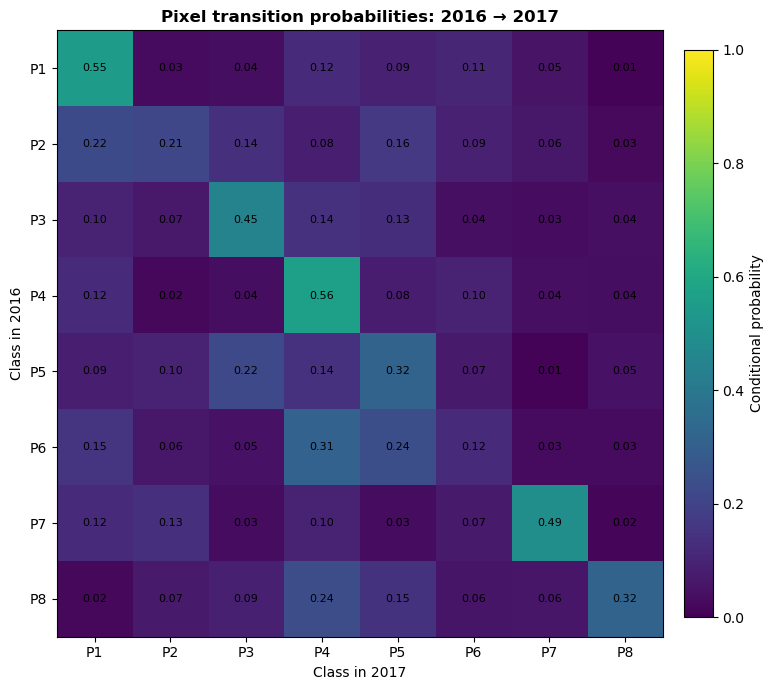


Processing transition 2017 → 2018

2017 → 2018 row-normalized transition probabilities


,P1,P2,P3,P4,P5,P6,P7,P8
P1,0.327,0.154,0.078,0.186,0.145,0.063,0.042,0.007
P2,0.044,0.250,0.126,0.181,0.199,0.069,0.075,0.056
P3,0.037,0.072,0.425,0.090,0.330,0.019,0.013,0.014
P4,0.041,0.009,0.083,0.642,0.130,0.072,0.010,0.014
P5,0.055,0.076,0.125,0.179,0.421,0.112,0.005,0.026
P6,0.108,0.042,0.046,0.415,0.179,0.171,0.023,0.015
P7,0.100,0.076,0.080,0.278,0.037,0.035,0.358,0.035
P8,0.031,0.021,0.132,0.322,0.194,0.059,0.015,0.225


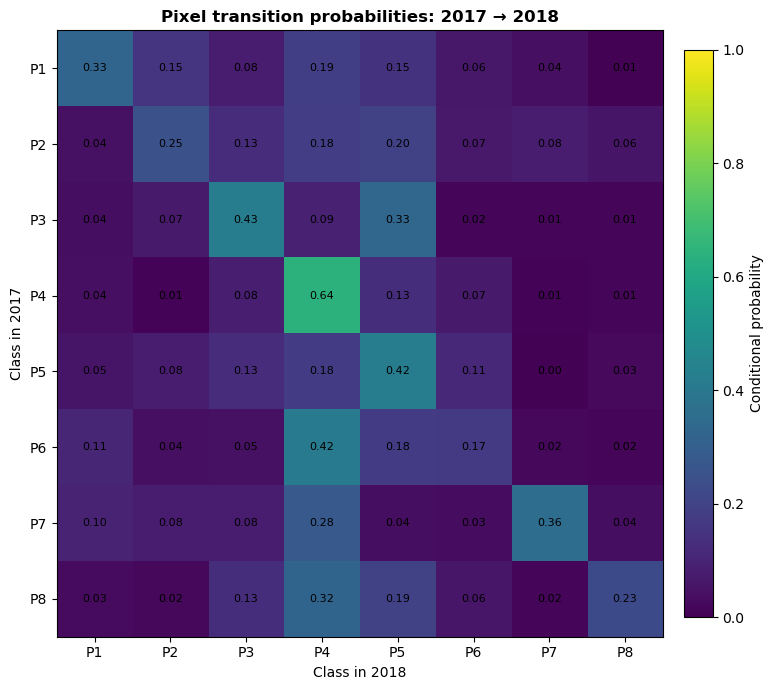


Processing transition 2018 → 2019

2018 → 2019 row-normalized transition probabilities


,P1,P2,P3,P4,P5,P6,P7,P8
P1,0.567,0.079,0.079,0.115,0.043,0.041,0.059,0.017
P2,0.152,0.419,0.223,0.027,0.076,0.020,0.078,0.004
P3,0.064,0.080,0.525,0.182,0.068,0.038,0.021,0.021
P4,0.112,0.022,0.052,0.591,0.066,0.102,0.028,0.025
P5,0.120,0.102,0.250,0.140,0.260,0.111,0.008,0.009
P6,0.171,0.055,0.048,0.226,0.180,0.276,0.034,0.010
P7,0.123,0.057,0.060,0.175,0.012,0.019,0.534,0.019
P8,0.032,0.024,0.039,0.356,0.085,0.096,0.038,0.331


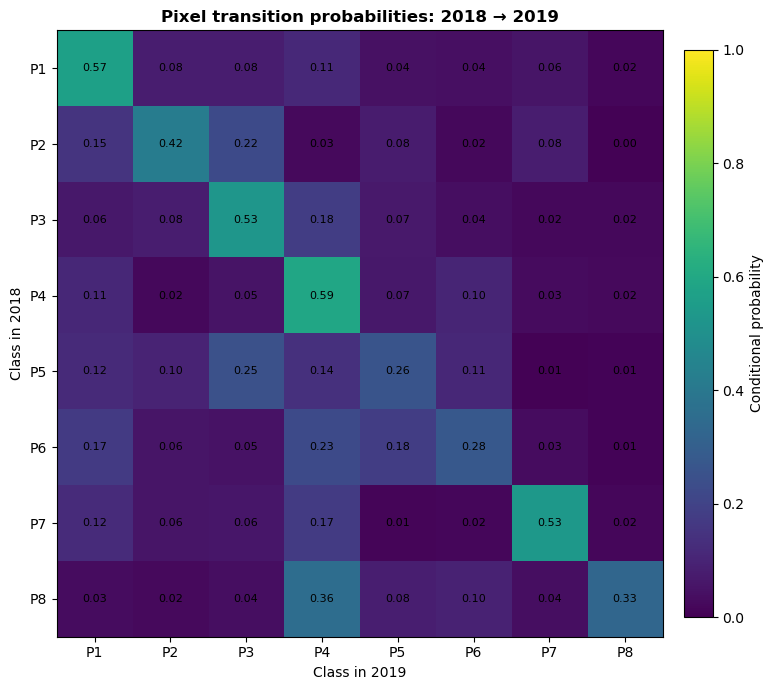


Processing transition 2019 → 2020

2019 → 2020 row-normalized transition probabilities


,P1,P2,P3,P4,P5,P6,P7,P8
P1,0.437,0.108,0.158,0.109,0.084,0.040,0.060,0.005
P2,0.070,0.333,0.329,0.043,0.123,0.033,0.060,0.009
P3,0.040,0.048,0.649,0.108,0.080,0.055,0.011,0.009
P4,0.081,0.010,0.110,0.587,0.047,0.085,0.046,0.034
P5,0.070,0.065,0.178,0.155,0.243,0.260,0.009,0.020
P6,0.148,0.036,0.080,0.299,0.151,0.234,0.023,0.030
P7,0.075,0.101,0.091,0.090,0.018,0.013,0.600,0.013
P8,0.046,0.005,0.079,0.403,0.023,0.045,0.047,0.352


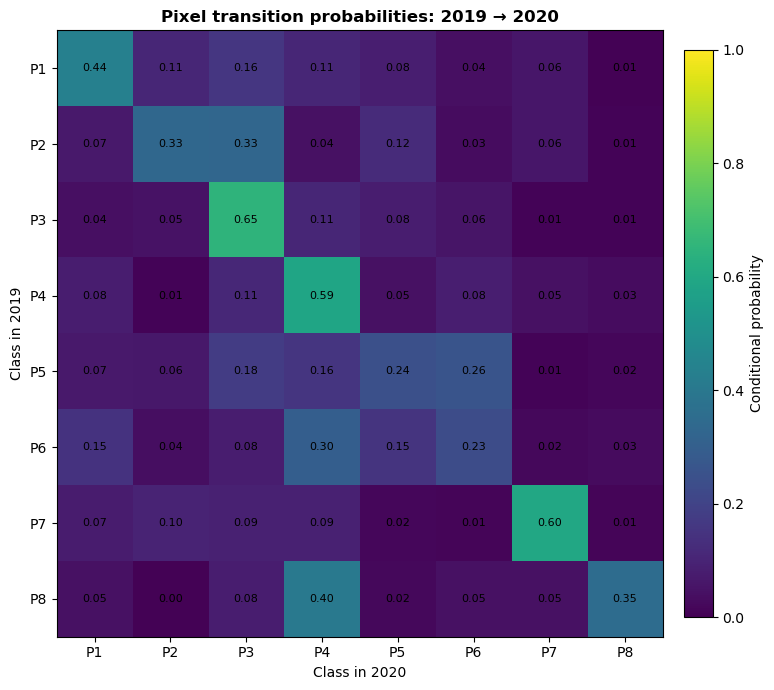


Processing transition 2020 → 2021

2020 → 2021 row-normalized transition probabilities


,P1,P2,P3,P4,P5,P6,P7,P8
P1,0.704,0.027,0.072,0.083,0.039,0.036,0.036,0.003
P2,0.335,0.345,0.097,0.021,0.054,0.016,0.126,0.005
P3,0.063,0.105,0.519,0.023,0.216,0.008,0.024,0.042
P4,0.126,0.008,0.058,0.619,0.057,0.068,0.025,0.040
P5,0.211,0.094,0.180,0.094,0.280,0.072,0.012,0.056
P6,0.089,0.009,0.053,0.452,0.110,0.249,0.019,0.018
P7,0.185,0.015,0.020,0.068,0.003,0.003,0.696,0.010
P8,0.040,0.008,0.060,0.373,0.054,0.020,0.030,0.415


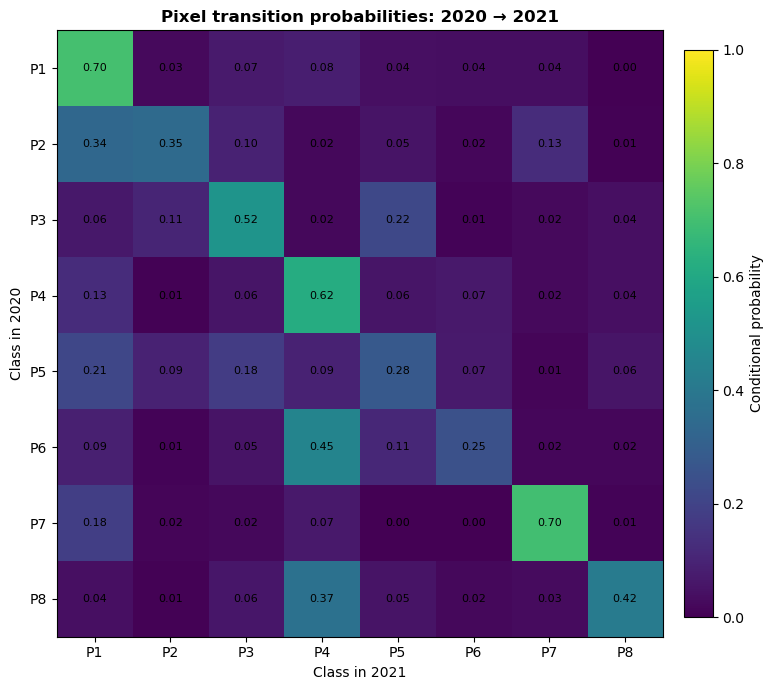


Processing transition 2021 → 2022

2021 → 2022 row-normalized transition probabilities


,P1,P2,P3,P4,P5,P6,P7,P8
P1,0.611,0.029,0.068,0.127,0.074,0.064,0.025,0.002
P2,0.196,0.227,0.325,0.058,0.139,0.027,0.024,0.004
P3,0.101,0.043,0.447,0.142,0.169,0.035,0.033,0.031
P4,0.044,0.003,0.014,0.671,0.080,0.101,0.014,0.072
P5,0.088,0.044,0.278,0.172,0.245,0.098,0.014,0.061
P6,0.116,0.007,0.025,0.334,0.247,0.245,0.008,0.018
P7,0.196,0.032,0.018,0.365,0.017,0.043,0.316,0.013
P8,0.028,0.016,0.080,0.381,0.093,0.086,0.052,0.263


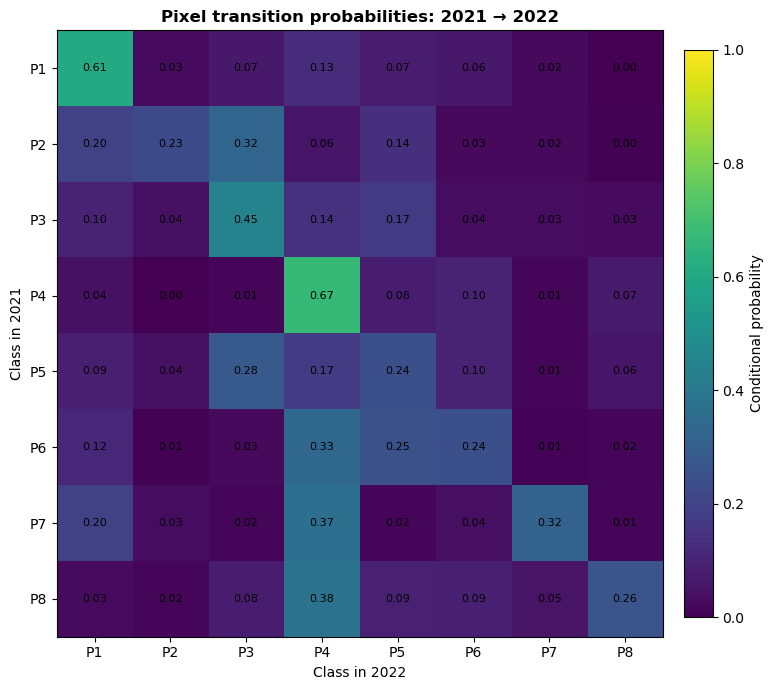


Processing transition 2022 → 2023

2022 → 2023 row-normalized transition probabilities


,P1,P2,P3,P4,P5,P6,P7,P8
P1,0.402,0.174,0.101,0.068,0.144,0.047,0.059,0.006
P2,0.045,0.410,0.225,0.047,0.190,0.042,0.029,0.012
P3,0.021,0.118,0.550,0.056,0.188,0.042,0.007,0.018
P4,0.067,0.009,0.037,0.669,0.036,0.091,0.072,0.019
P5,0.054,0.099,0.230,0.171,0.247,0.184,0.003,0.012
P6,0.108,0.024,0.047,0.383,0.103,0.288,0.023,0.023
P7,0.133,0.090,0.135,0.162,0.016,0.035,0.399,0.029
P8,0.031,0.006,0.041,0.591,0.045,0.107,0.012,0.168


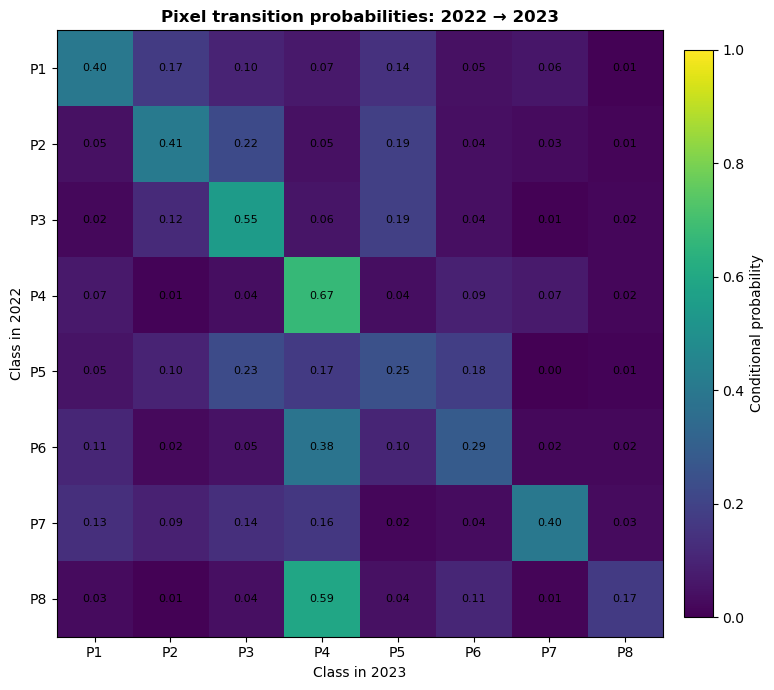


Processing transition 2023 → 2024

2023 → 2024 row-normalized transition probabilities


,P1,P2,P3,P4,P5,P6,P7,P8
P1,0.540,0.039,0.066,0.169,0.079,0.043,0.057,0.006
P2,0.240,0.262,0.210,0.116,0.057,0.014,0.089,0.012
P3,0.066,0.067,0.366,0.270,0.112,0.023,0.025,0.071
P4,0.075,0.009,0.029,0.509,0.235,0.081,0.033,0.030
P5,0.090,0.059,0.181,0.295,0.248,0.040,0.005,0.082
P6,0.082,0.029,0.027,0.230,0.472,0.128,0.020,0.012
P7,0.172,0.091,0.013,0.118,0.021,0.015,0.563,0.006
P8,0.049,0.015,0.049,0.414,0.080,0.042,0.047,0.304


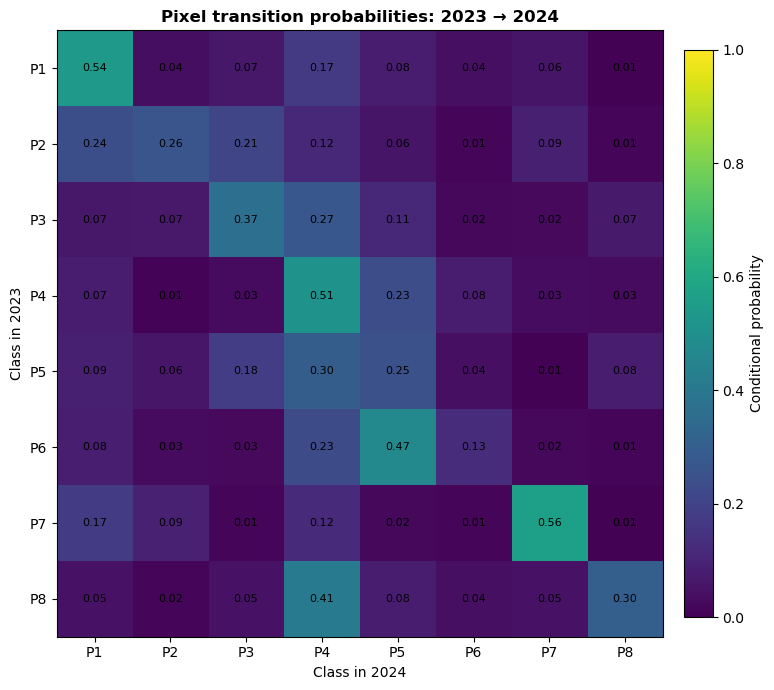


Processing transition 2024 → 2025

2024 → 2025 row-normalized transition probabilities


,P1,P2,P3,P4,P5,P6,P7,P8
P1,0.438,0.112,0.110,0.107,0.075,0.053,0.088,0.017
P2,0.089,0.482,0.212,0.029,0.069,0.019,0.095,0.004
P3,0.119,0.166,0.401,0.110,0.092,0.083,0.014,0.015
P4,0.086,0.010,0.094,0.584,0.025,0.122,0.025,0.055
P5,0.048,0.044,0.150,0.269,0.192,0.277,0.006,0.014
P6,0.091,0.017,0.046,0.371,0.098,0.346,0.013,0.018
P7,0.160,0.098,0.072,0.165,0.009,0.009,0.473,0.013
P8,0.111,0.024,0.138,0.335,0.063,0.084,0.055,0.190


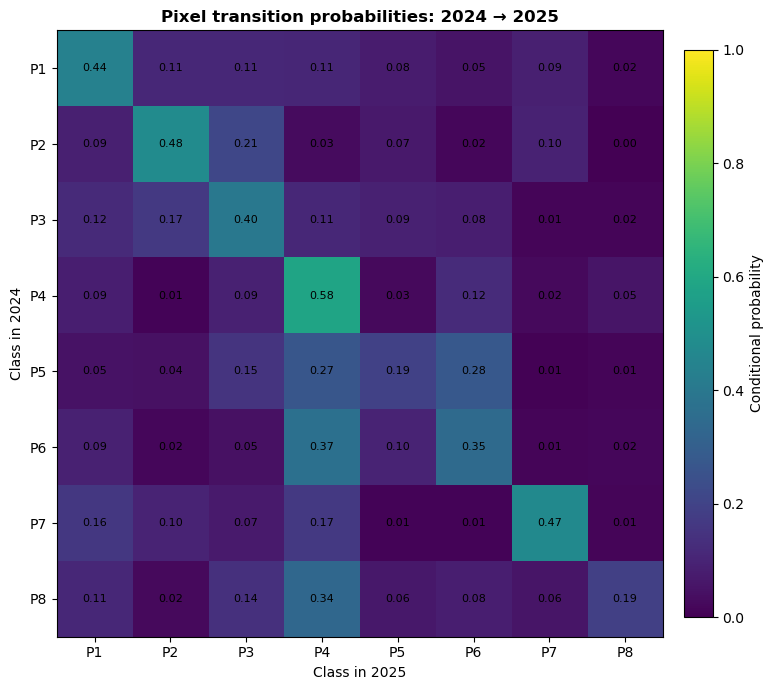


CLASS-SPECIFIC PIXEL PERSISTENCE


,parent,P1,P2,P3,P4,P5,P6,P7,P8
year_from,year_to,,,,,,,,
2016,2017,0.552,0.212,0.446,0.563,0.317,0.125,0.494,0.318
2017,2018,0.327,0.250,0.425,0.642,0.421,0.171,0.358,0.225
2018,2019,0.567,0.419,0.525,0.591,0.260,0.276,0.534,0.331
2019,2020,0.437,0.333,0.649,0.587,0.243,0.234,0.600,0.352
2020,2021,0.704,0.345,0.519,0.619,0.280,0.249,0.696,0.415
2021,2022,0.611,0.227,0.447,0.671,0.245,0.245,0.316,0.263
2022,2023,0.402,0.410,0.550,0.669,0.247,0.288,0.399,0.168
2023,2024,0.540,0.262,0.366,0.509,0.248,0.128,0.563,0.304
2024,2025,0.438,0.482,0.401,0.584,0.192,0.346,0.473,0.190



OVERALL PIXEL PERSISTENCE


,year_from,year_to,n_paired_pixels,n_unchanged_pixels,overall_persistence,overall_change
0,2016,2017,34829303,15158639,0.4352,0.5648
1,2017,2018,34912804,14603209,0.4183,0.5817
2,2018,2019,34928942,16180511,0.4632,0.5368
3,2019,2020,34946620,16606173,0.4752,0.5248
4,2020,2021,34957335,18108561,0.5180,0.4820
5,2021,2022,34947631,16467208,0.4712,0.5288
6,2022,2023,34953824,16412842,0.4696,0.5304
7,2023,2024,34960327,13881518,0.3971,0.6029
8,2024,2025,34955243,14768703,0.4225,0.5775


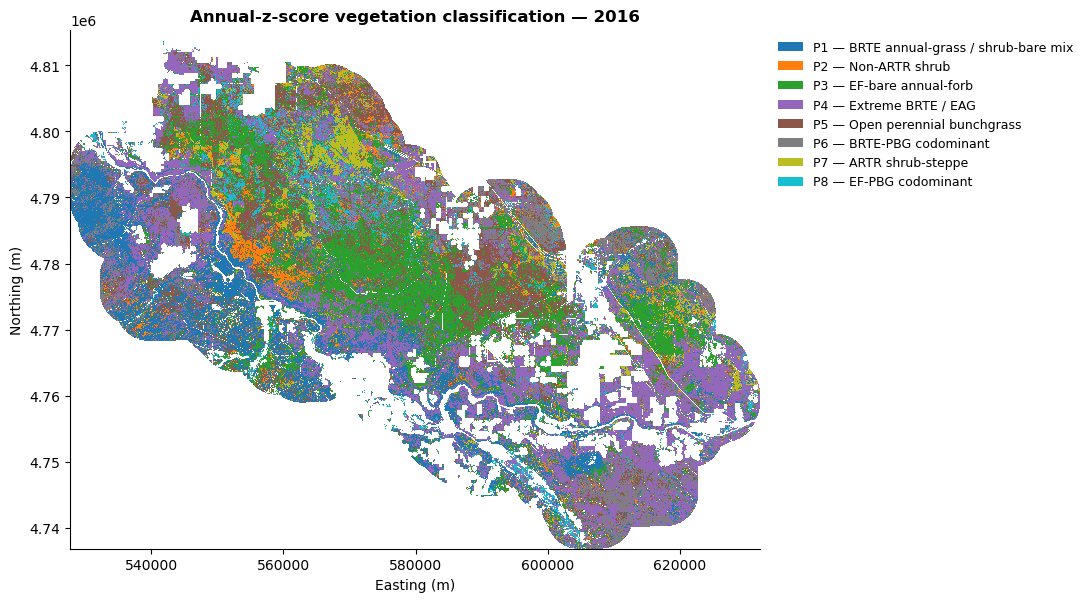

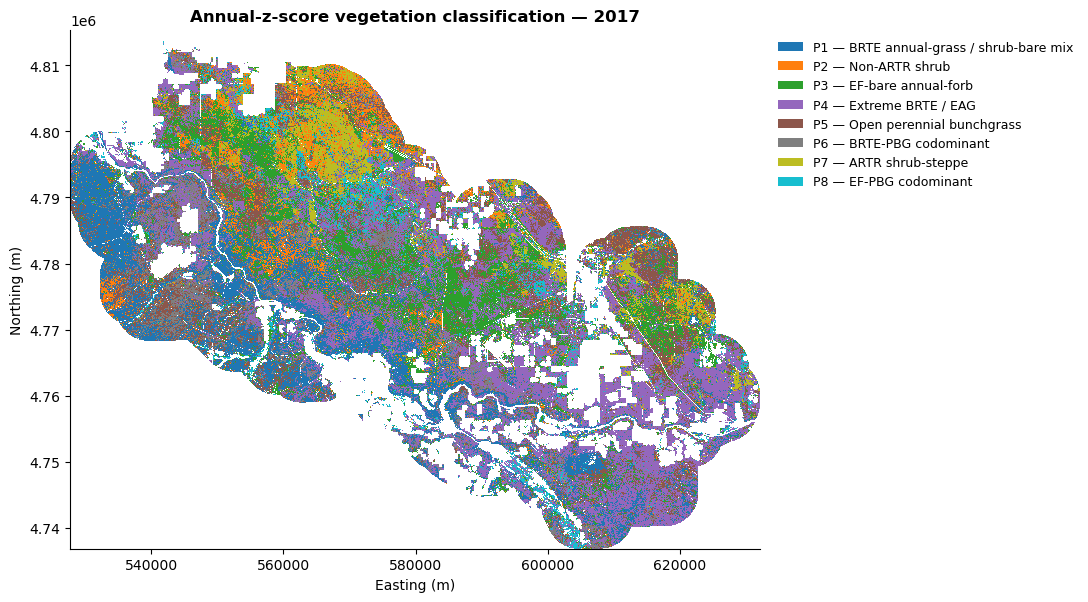

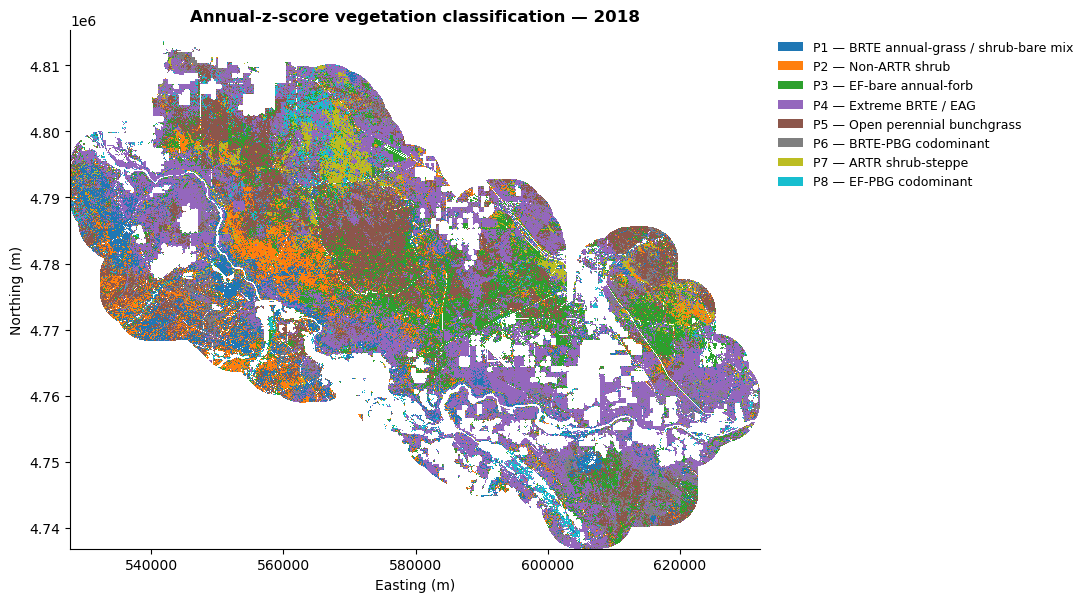

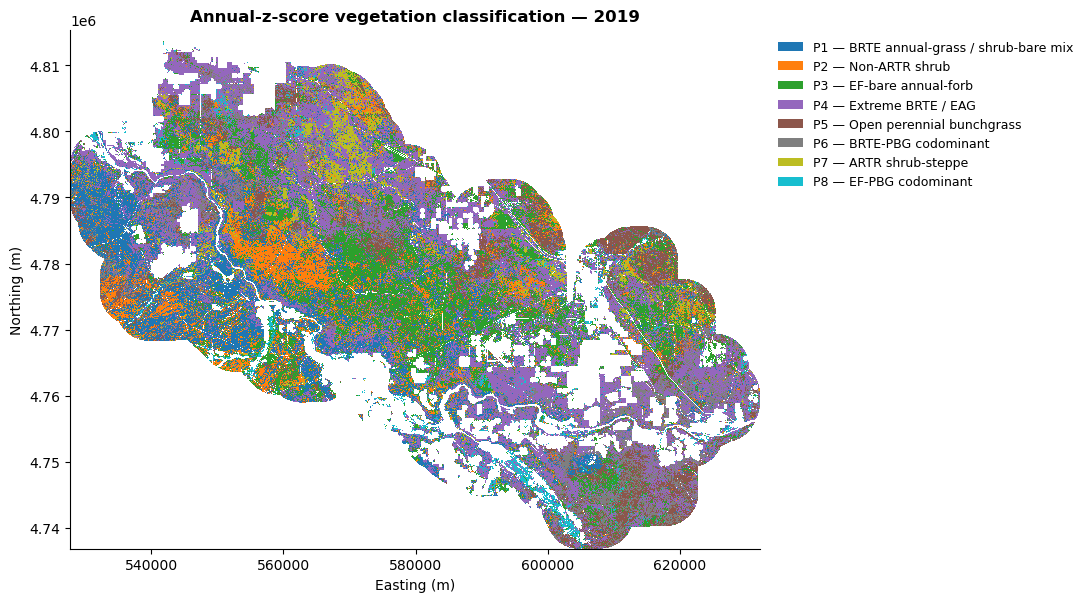

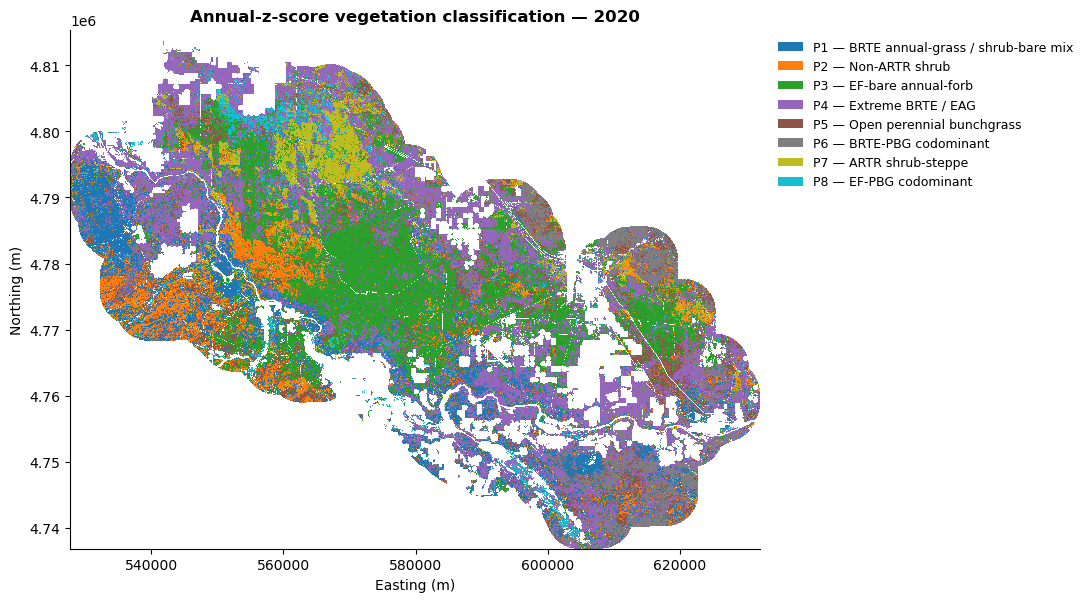

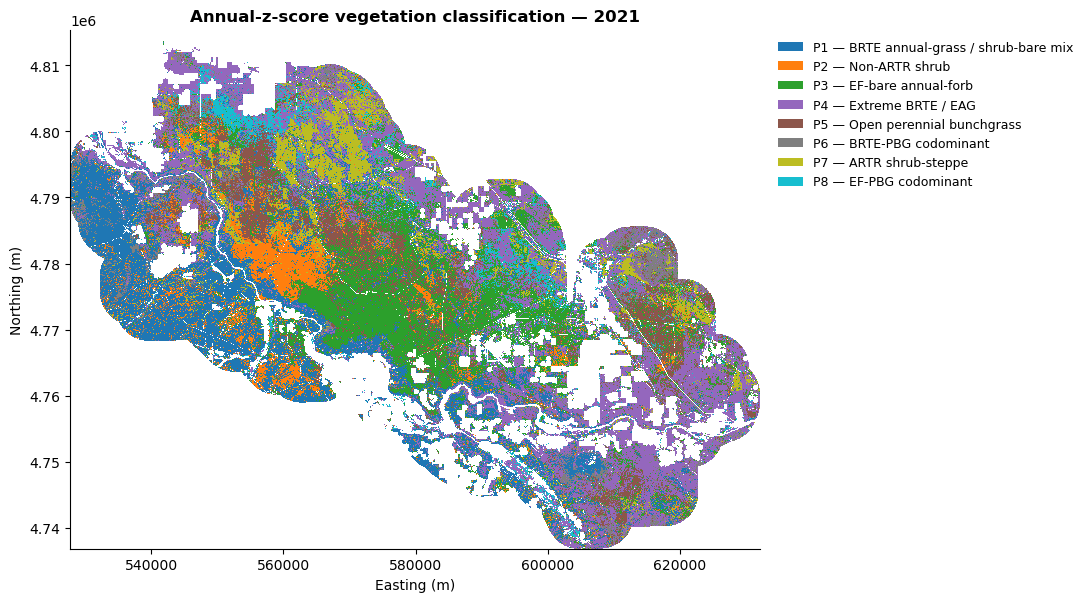

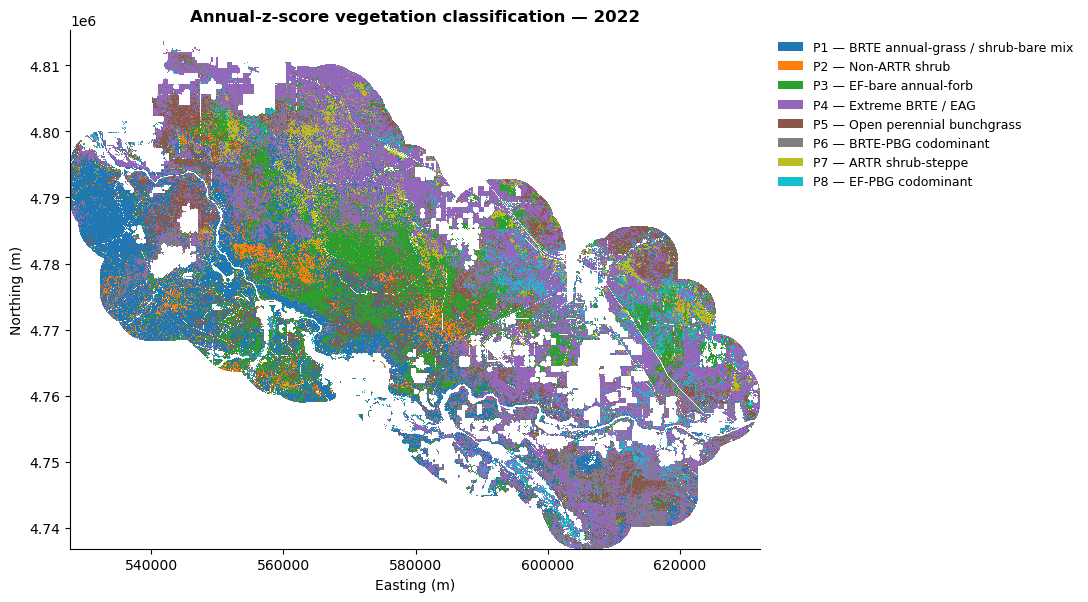

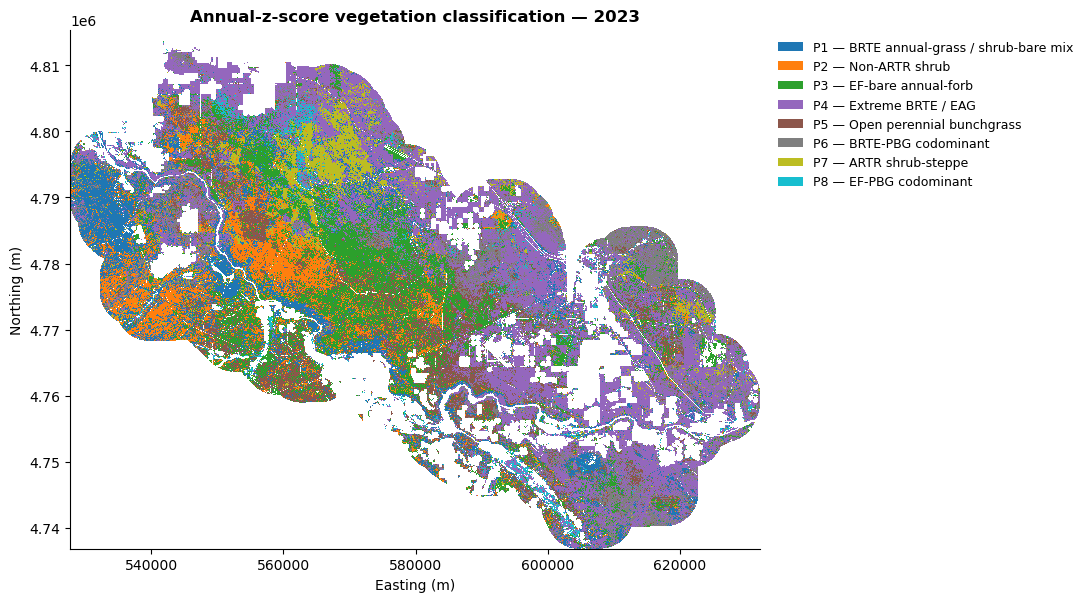

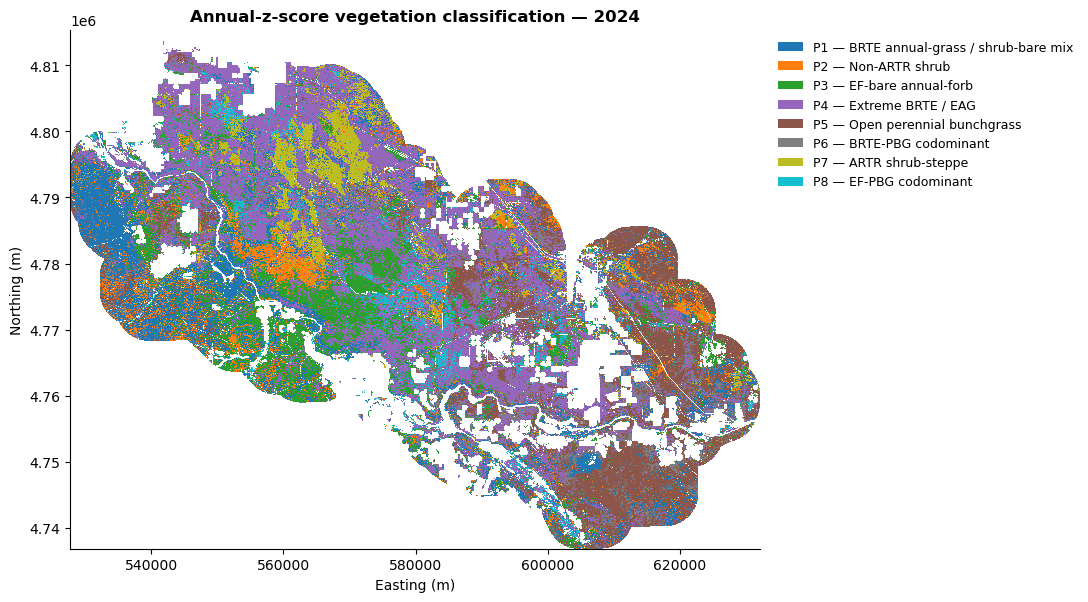

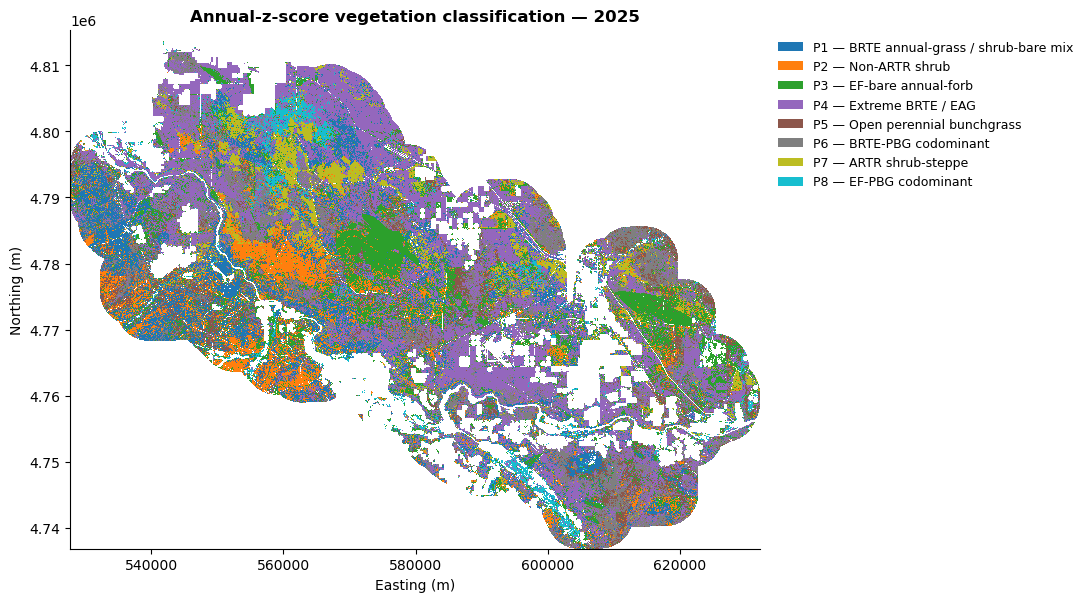


Transition diagnostics and classified-map visualization complete.


In [20]:
# =============================================================================
# 17. PIXELWISE TEMPORAL TRANSITIONS + CLASSIFIED MAP VISUALIZATION
# =============================================================================

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


# =============================================================================
# SETTINGS
# =============================================================================

SHOW_TRANSITION_HEATMAPS = True
SHOW_CLASSIFIED_MAPS = True

SAVE_TRANSITION_HEATMAPS = True
SAVE_CLASSIFIED_MAPS = True


# -----------------------------------------------------------------------------
# ECOLOGICAL CLASS LABELS
# -----------------------------------------------------------------------------

PARENT_LABELS = {
    1: "BRTE annual-grass / shrub-bare mix",
    2: "Non-ARTR shrub",
    3: "EF-bare annual-forb",
    4: "Extreme BRTE / EAG",
    5: "Open perennial bunchgrass",
    6: "BRTE-PBG codominant",
    7: "ARTR shrub-steppe",
    8: "EF-PBG codominant",
}


# -----------------------------------------------------------------------------
# CONSISTENT MAP PALETTE
# -----------------------------------------------------------------------------

cmap = plt.get_cmap(
    "tab10",
    8,
)

class_norm = BoundaryNorm(
    np.arange(
        0.5,
        9.5,
        1,
    ),
    cmap.N,
)


# =============================================================================
# CLASSIFIED RASTER PATH
# =============================================================================

def classified_path(
    year,
):

    return (
        OUTPUT_DIR
        / (
            f"ParentML_AnnualZScore_"
            f"{MODEL_FOR_MAPPING}_{year}_class.tif"
        )
    )


# =============================================================================
# GRID CONSISTENCY CHECK
# =============================================================================

reference_grid = None

for year in YEARS_TO_MAP:

    path = classified_path(
        year
    )

    if not path.exists():

        raise FileNotFoundError(
            f"Missing classified raster:\n{path}"
        )

    with rasterio.open(
        path
    ) as src:

        grid = {
            "crs": src.crs,
            "transform": src.transform,
            "width": src.width,
            "height": src.height,
        }

    if reference_grid is None:

        reference_grid = grid

    else:

        if grid != reference_grid:

            raise RuntimeError(
                f"Classified raster grid differs in {year}."
            )


print(
    "All classified rasters share the same grid."
)


# =============================================================================
# YEAR-TO-YEAR TRANSITION MATRICES
#
# T_ab,t = P(S_t+1 = b | S_t = a)
#
# Rows = class at year t
# Columns = class at year t+1
# =============================================================================

transition_count_records = []
transition_probability_records = []
persistence_records = []
overall_transition_records = []


for year_from, year_to in zip(
    YEARS_TO_MAP[:-1],
    YEARS_TO_MAP[1:],
):

    path_from = classified_path(
        year_from
    )

    path_to = classified_path(
        year_to
    )

    print(
        f"\nProcessing transition "
        f"{year_from} → {year_to}"
    )


    # -------------------------------------------------------------------------
    # READ NATIVE CLASSIFICATION RASTERS
    # -------------------------------------------------------------------------

    with rasterio.open(
        path_from
    ) as src_from:

        state_from = src_from.read(
            1,
            masked=False,
        )

    with rasterio.open(
        path_to
    ) as src_to:

        state_to = src_to.read(
            1,
            masked=False,
        )


    # -------------------------------------------------------------------------
    # VALID PAIRED PIXELS
    # -------------------------------------------------------------------------

    valid = (
        np.isin(
            state_from,
            VEG_PARENT_CODES,
        )
        & np.isin(
            state_to,
            VEG_PARENT_CODES,
        )
    )

    a = state_from[
        valid
    ].astype(
        np.int16
    )

    b = state_to[
        valid
    ].astype(
        np.int16
    )

    n_paired = len(
        a
    )


    # -------------------------------------------------------------------------
    # FAST 8 x 8 TRANSITION COUNTS
    # -------------------------------------------------------------------------

    transition_index = (
        (
            a
            - 1
        )
        * 8
        + (
            b
            - 1
        )
    )

    counts = np.bincount(
        transition_index,
        minlength=64,
    ).reshape(
        8,
        8,
    )


    # -------------------------------------------------------------------------
    # ROW-NORMALIZED TRANSITION PROBABILITIES
    # -------------------------------------------------------------------------

    row_totals = counts.sum(
        axis=1,
        keepdims=True,
    )

    probabilities = np.divide(
        counts,
        row_totals,
        out=np.zeros_like(
            counts,
            dtype=float,
        ),
        where=(
            row_totals
            > 0
        ),
    )


    # -------------------------------------------------------------------------
    # OVERALL PIXEL PERSISTENCE
    # -------------------------------------------------------------------------

    unchanged_pixels = int(
        np.trace(
            counts
        )
    )

    overall_persistence = (
        unchanged_pixels
        / n_paired
        if n_paired > 0
        else np.nan
    )

    overall_transition_records.append(
        {
            "year_from": year_from,
            "year_to": year_to,
            "n_paired_pixels": n_paired,
            "n_unchanged_pixels": unchanged_pixels,
            "overall_persistence": overall_persistence,
            "overall_change": (
                1.0
                - overall_persistence
            ),
        }
    )


    # -------------------------------------------------------------------------
    # LONG-FORM OUTPUT
    # -------------------------------------------------------------------------

    for i, parent_from in enumerate(
        VEG_PARENT_CODES
    ):

        for j, parent_to in enumerate(
            VEG_PARENT_CODES
        ):

            transition_count_records.append(
                {
                    "year_from": year_from,
                    "year_to": year_to,
                    "parent_from": parent_from,
                    "parent_to": parent_to,
                    "n_pixels": int(
                        counts[
                            i,
                            j
                        ]
                    ),
                }
            )

            transition_probability_records.append(
                {
                    "year_from": year_from,
                    "year_to": year_to,
                    "parent_from": parent_from,
                    "parent_to": parent_to,
                    "probability": float(
                        probabilities[
                            i,
                            j
                        ]
                    ),
                }
            )


    # -------------------------------------------------------------------------
    # CLASS-SPECIFIC PERSISTENCE
    # -------------------------------------------------------------------------

    for i, parent in enumerate(
        VEG_PARENT_CODES
    ):

        n_origin = int(
            row_totals[
                i,
                0
            ]
        )

        n_persistent = int(
            counts[
                i,
                i
            ]
        )

        persistence = (
            n_persistent
            / n_origin
            if n_origin > 0
            else np.nan
        )

        persistence_records.append(
            {
                "year_from": year_from,
                "year_to": year_to,
                "parent": parent,
                "parent_label": PARENT_LABELS[
                    parent
                ],
                "n_origin_pixels": n_origin,
                "n_persistent_pixels": n_persistent,
                "persistence_probability": persistence,
            }
        )


    # -------------------------------------------------------------------------
    # DISPLAY MATRIX AS TABLE
    # -------------------------------------------------------------------------

    transition_df = pd.DataFrame(
        probabilities,
        index=[
            f"P{i}"
            for i in VEG_PARENT_CODES
        ],
        columns=[
            f"P{i}"
            for i in VEG_PARENT_CODES
        ],
    )

    print(
        f"\n{year_from} → {year_to} "
        f"row-normalized transition probabilities"
    )

    display(
        transition_df.round(
            3
        )
    )


    # -------------------------------------------------------------------------
    # TRANSITION HEATMAP
    # -------------------------------------------------------------------------

    if SHOW_TRANSITION_HEATMAPS:

        fig, ax = plt.subplots(
            figsize=(
                8,
                7,
            )
        )

        image = ax.imshow(
            probabilities,
            vmin=0,
            vmax=1,
            aspect="equal",
        )

        ax.set_xticks(
            np.arange(
                8
            )
        )

        ax.set_xticklabels(
            [
                f"P{i}"
                for i in VEG_PARENT_CODES
            ]
        )

        ax.set_yticks(
            np.arange(
                8
            )
        )

        ax.set_yticklabels(
            [
                f"P{i}"
                for i in VEG_PARENT_CODES
            ]
        )

        ax.set_xlabel(
            f"Class in {year_to}"
        )

        ax.set_ylabel(
            f"Class in {year_from}"
        )

        ax.set_title(
            f"Pixel transition probabilities: "
            f"{year_from} → {year_to}",
            fontweight="bold",
        )


        for i in range(
            8
        ):

            for j in range(
                8
            ):

                value = probabilities[
                    i,
                    j
                ]

                ax.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )


        cbar = fig.colorbar(
            image,
            ax=ax,
            fraction=0.04,
            pad=0.03,
        )

        cbar.set_label(
            "Conditional probability"
        )

        fig.tight_layout()


        if SAVE_TRANSITION_HEATMAPS:

            fig.savefig(
                OUTPUT_DIR
                / (
                    f"AnnualZScore_transition_"
                    f"{year_from}_{year_to}.png"
                ),
                dpi=300,
                bbox_inches="tight",
            )


        plt.show()

        plt.close(
            fig
        )


    del state_from
    del state_to
    del a
    del b


# =============================================================================
# SAVE TRANSITION TABLES
# =============================================================================

transition_counts_long = pd.DataFrame(
    transition_count_records
)

transition_probabilities_long = pd.DataFrame(
    transition_probability_records
)

persistence_df = pd.DataFrame(
    persistence_records
)

overall_transition_df = pd.DataFrame(
    overall_transition_records
)


transition_counts_long.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_transition_counts_long.csv",
    index=False,
)

transition_probabilities_long.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_transition_probabilities_long.csv",
    index=False,
)

persistence_df.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_parent_persistence.csv",
    index=False,
)

overall_transition_df.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_overall_transition_summary.csv",
    index=False,
)


# =============================================================================
# PERSISTENCE SUMMARY TABLE
# =============================================================================

persistence_table = (
    persistence_df
    .pivot(
        index=[
            "year_from",
            "year_to",
        ],
        columns="parent",
        values="persistence_probability",
    )
    .rename(
        columns={
            i: f"P{i}"
            for i in VEG_PARENT_CODES
        }
    )
)

print(
    "\nCLASS-SPECIFIC PIXEL PERSISTENCE"
)

display(
    persistence_table.round(
        3
    )
)


print(
    "\nOVERALL PIXEL PERSISTENCE"
)

display(
    overall_transition_df.round(
        4
    )
)


# =============================================================================
# CLASSIFIED MAPS
# =============================================================================

legend_handles = [
    Patch(
        facecolor=cmap(
            parent - 1
        ),
        edgecolor="none",
        label=(
            f"P{parent} — "
            f"{PARENT_LABELS[parent]}"
        ),
    )
    for parent in VEG_PARENT_CODES
]


if SHOW_CLASSIFIED_MAPS:

    for year in YEARS_TO_MAP:

        path = classified_path(
            year
        )

        with rasterio.open(
            path
        ) as src:

            arr = src.read(
                1,
                masked=False,
            )

            bounds = src.bounds

        arr = np.ma.masked_where(
            ~np.isin(
                arr,
                VEG_PARENT_CODES,
            ),
            arr,
        )


        fig, ax = plt.subplots(
            figsize=(
                11,
                9,
            )
        )

        ax.imshow(
            arr,
            cmap=cmap,
            norm=class_norm,
            extent=[
                bounds.left,
                bounds.right,
                bounds.bottom,
                bounds.top,
            ],
            interpolation="nearest",
        )

        ax.set_title(
            f"Annual-z-score vegetation classification — {year}",
            fontweight="bold",
        )

        ax.set_xlabel(
            "Easting (m)"
        )

        ax.set_ylabel(
            "Northing (m)"
        )

        ax.legend(
            handles=legend_handles,
            loc="upper left",
            bbox_to_anchor=(
                1.01,
                1.0,
            ),
            frameon=False,
            fontsize=9,
        )

        ax.spines[
            "top"
        ].set_visible(
            False
        )

        ax.spines[
            "right"
        ].set_visible(
            False
        )

        fig.tight_layout()


        if SAVE_CLASSIFIED_MAPS:

            fig.savefig(
                OUTPUT_DIR
                / (
                    f"AnnualZScore_classified_map_"
                    f"{year}.png"
                ),
                dpi=300,
                bbox_inches="tight",
            )


        plt.show()

        plt.close(
            fig
        )


print(
    "\nTransition diagnostics and classified-map visualization complete."
)


THREE-YEAR TRAJECTORY: 2016 → 2017 → 2018


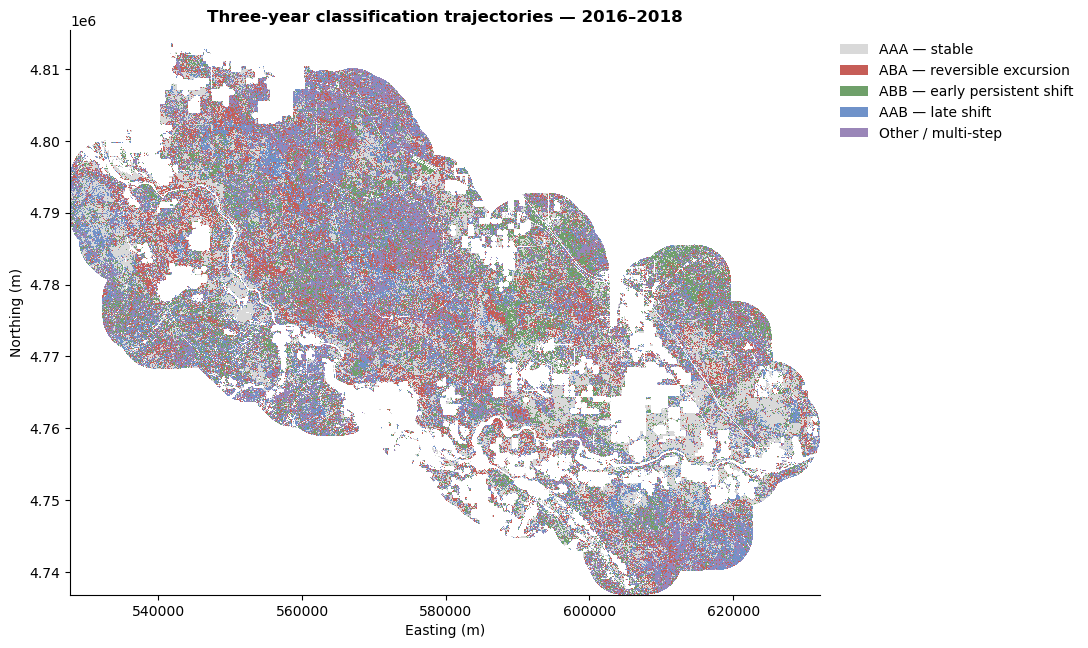

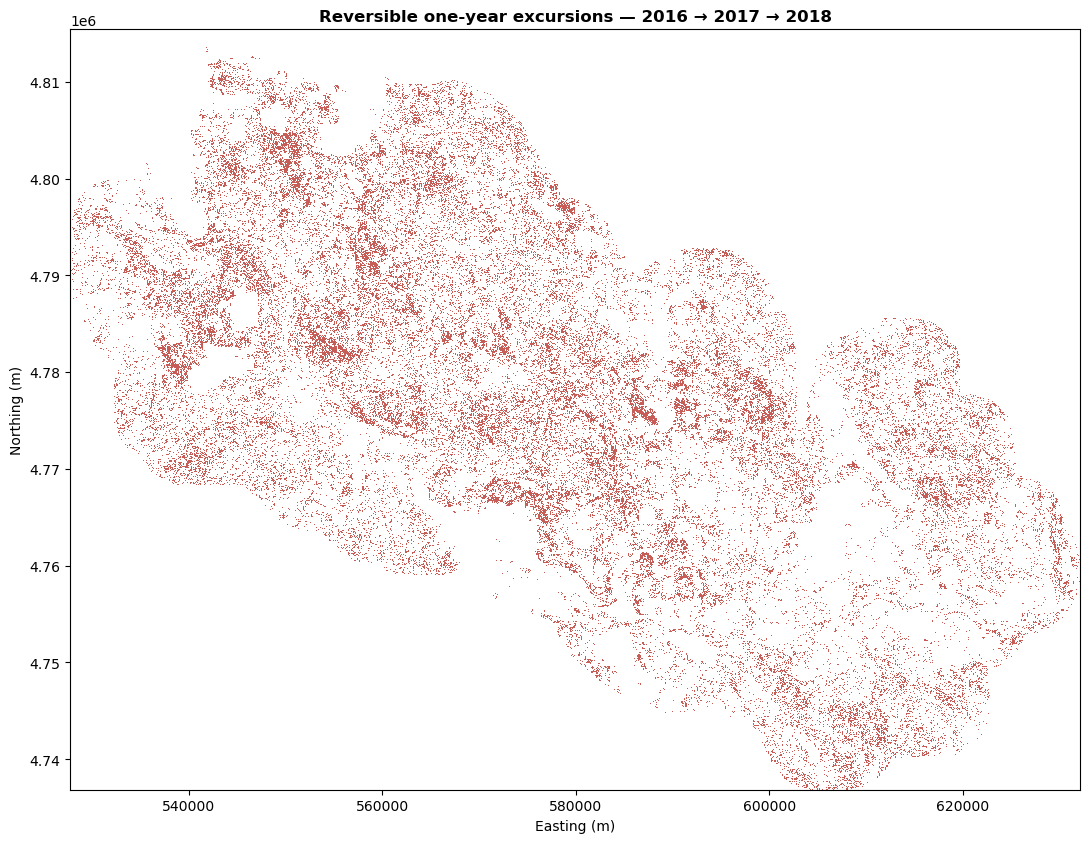


THREE-YEAR TRAJECTORY: 2017 → 2018 → 2019


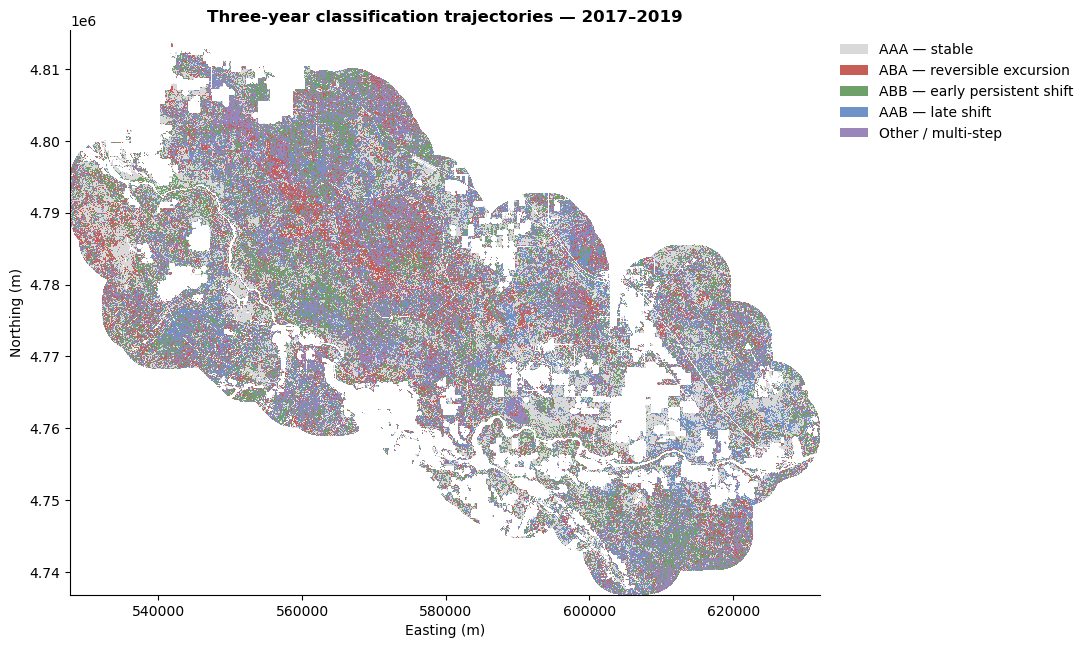

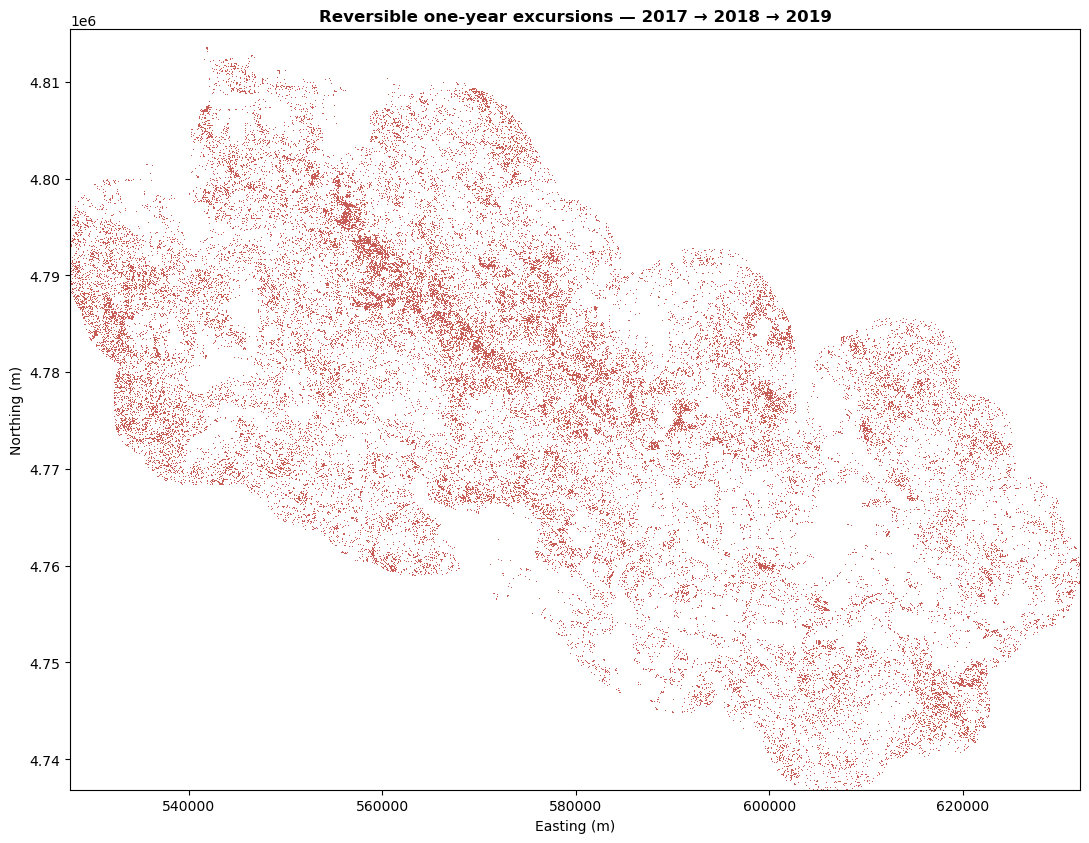


THREE-YEAR TRAJECTORY: 2018 → 2019 → 2020


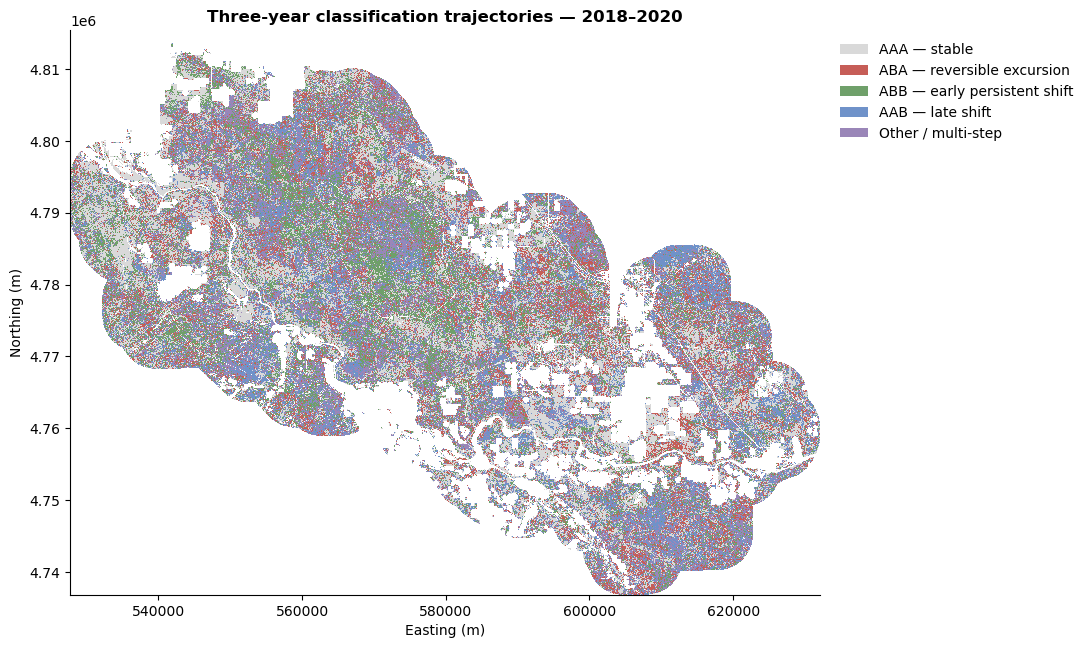

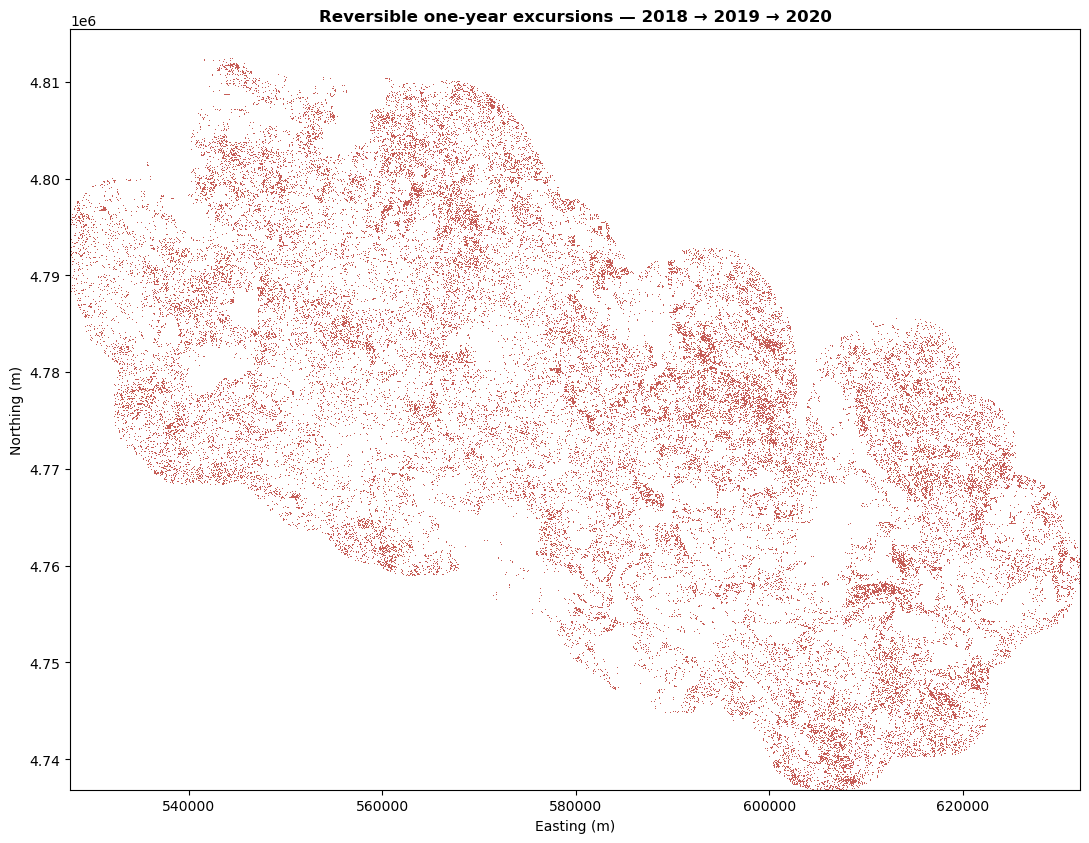


THREE-YEAR TRAJECTORY: 2019 → 2020 → 2021


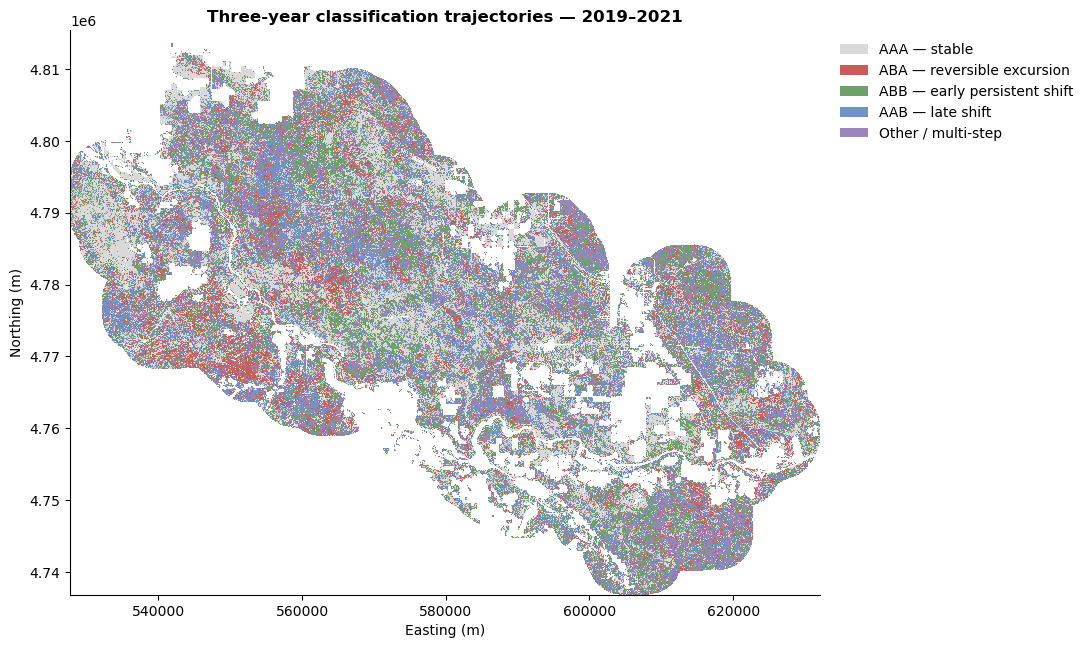

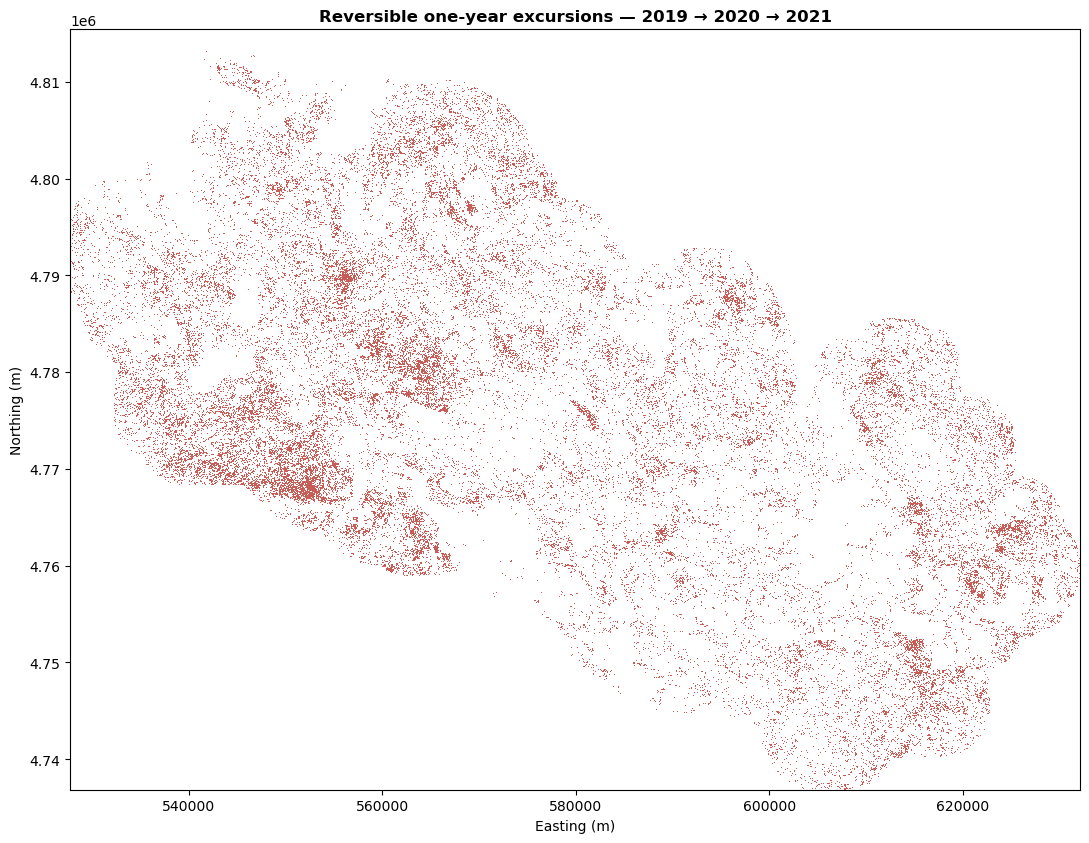


THREE-YEAR TRAJECTORY: 2020 → 2021 → 2022


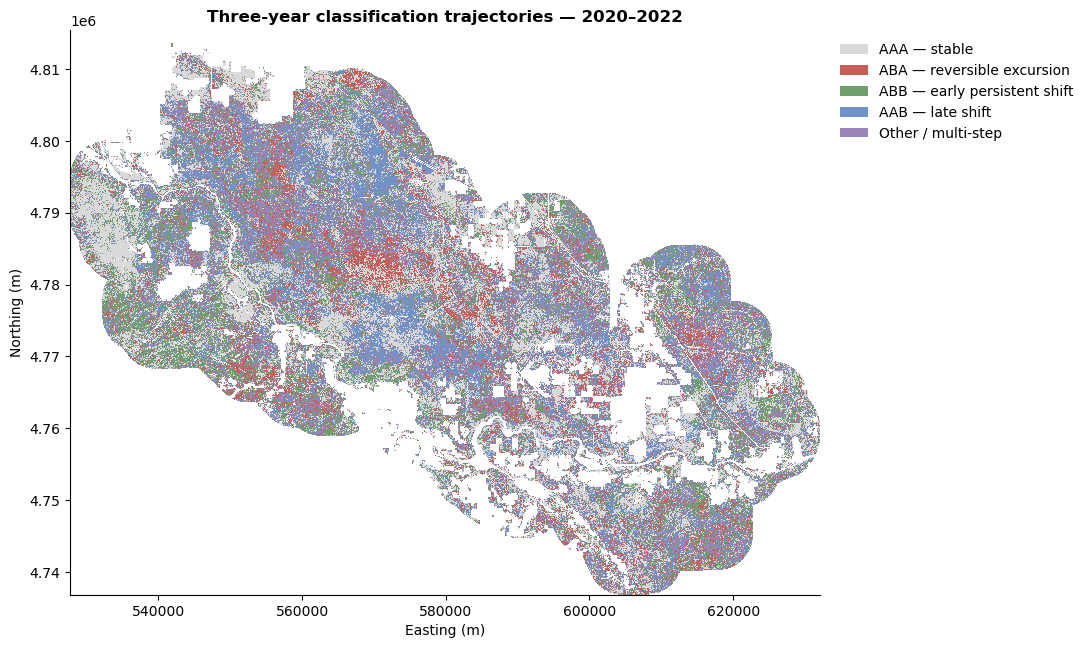

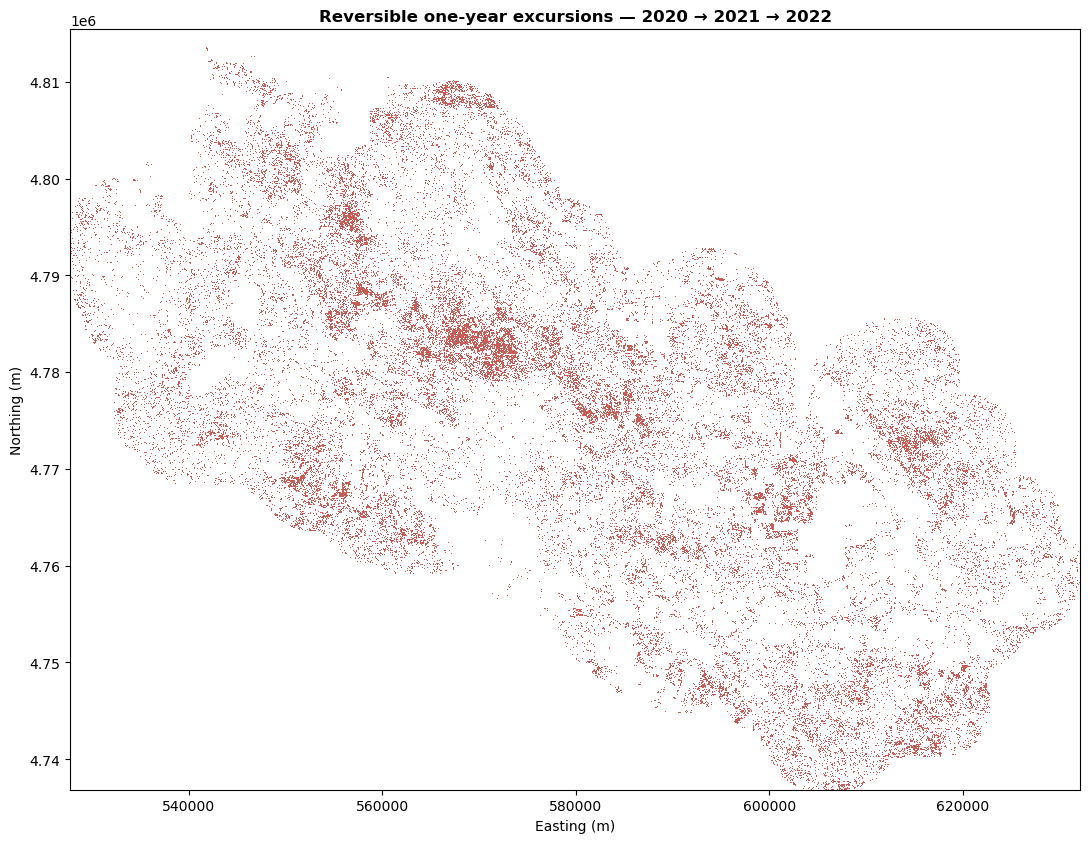


THREE-YEAR TRAJECTORY: 2021 → 2022 → 2023


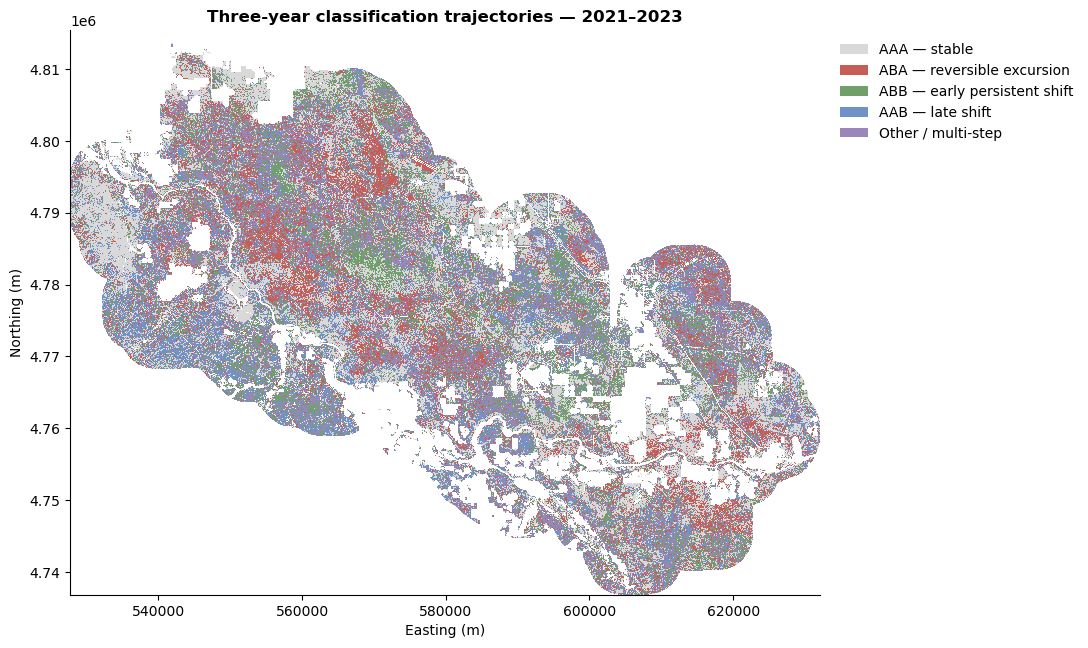

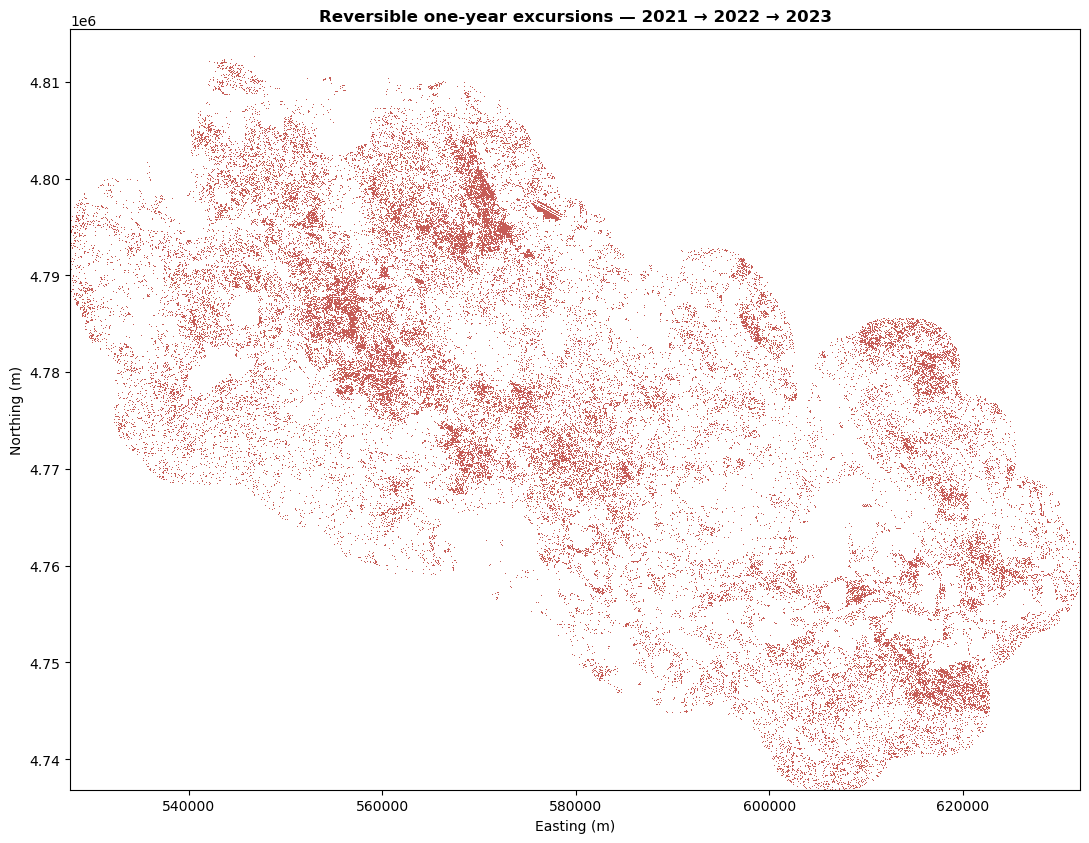


THREE-YEAR TRAJECTORY: 2022 → 2023 → 2024


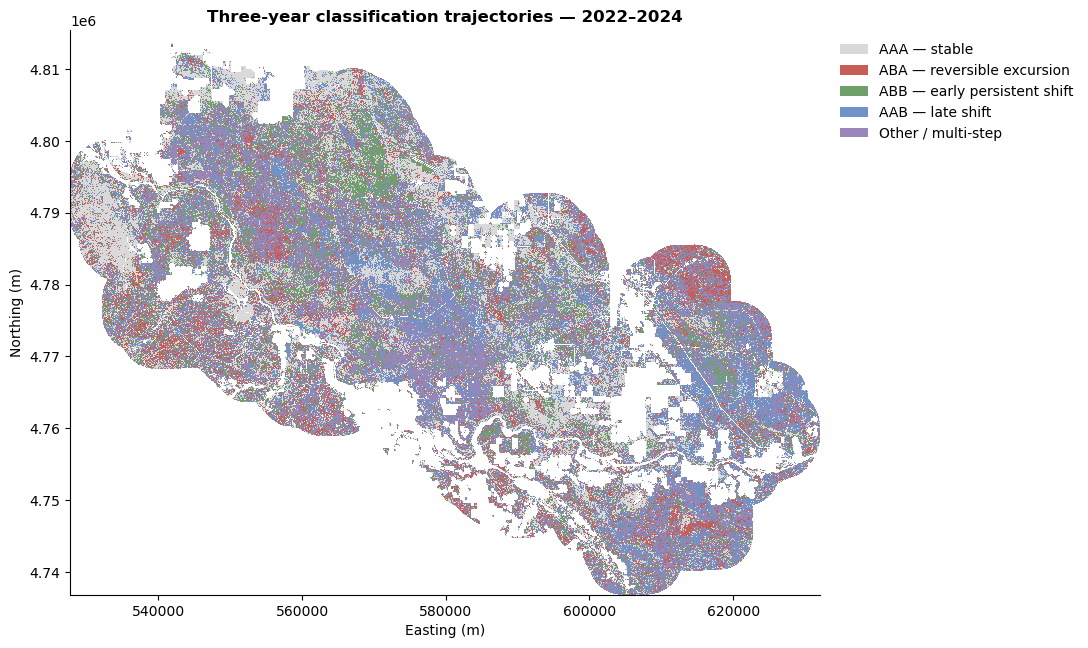

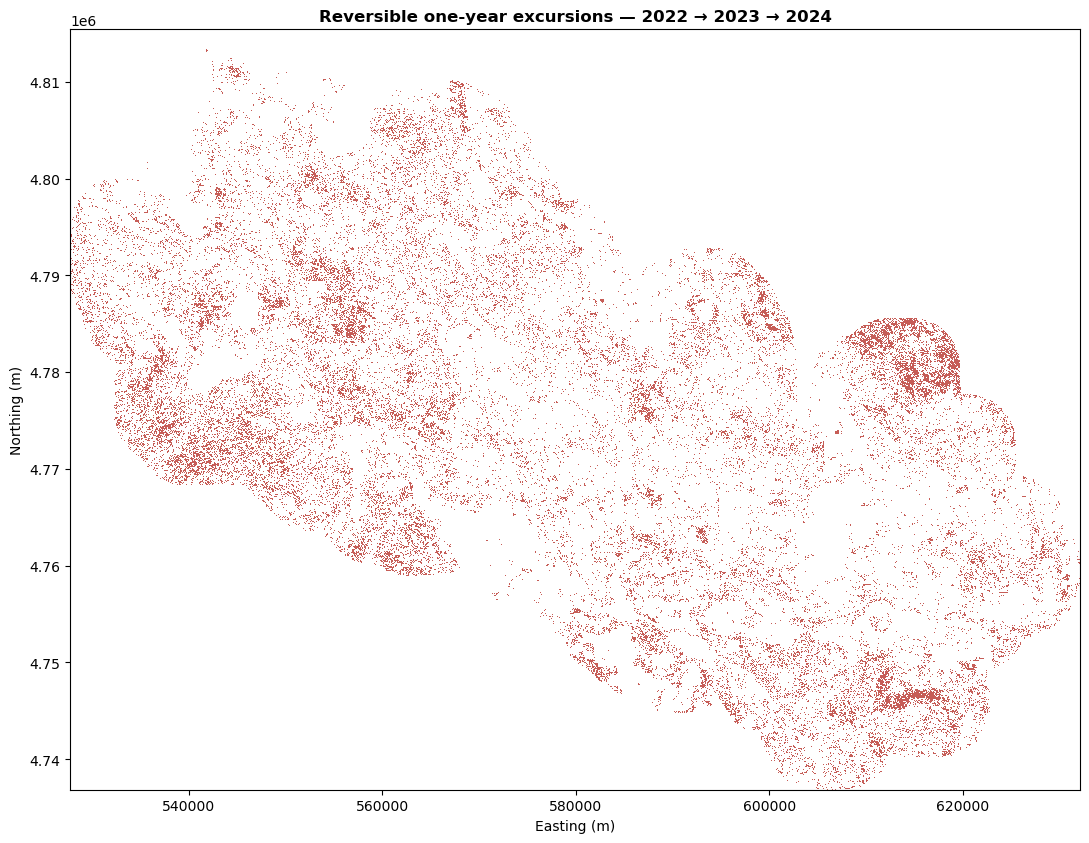


THREE-YEAR TRAJECTORY: 2023 → 2024 → 2025


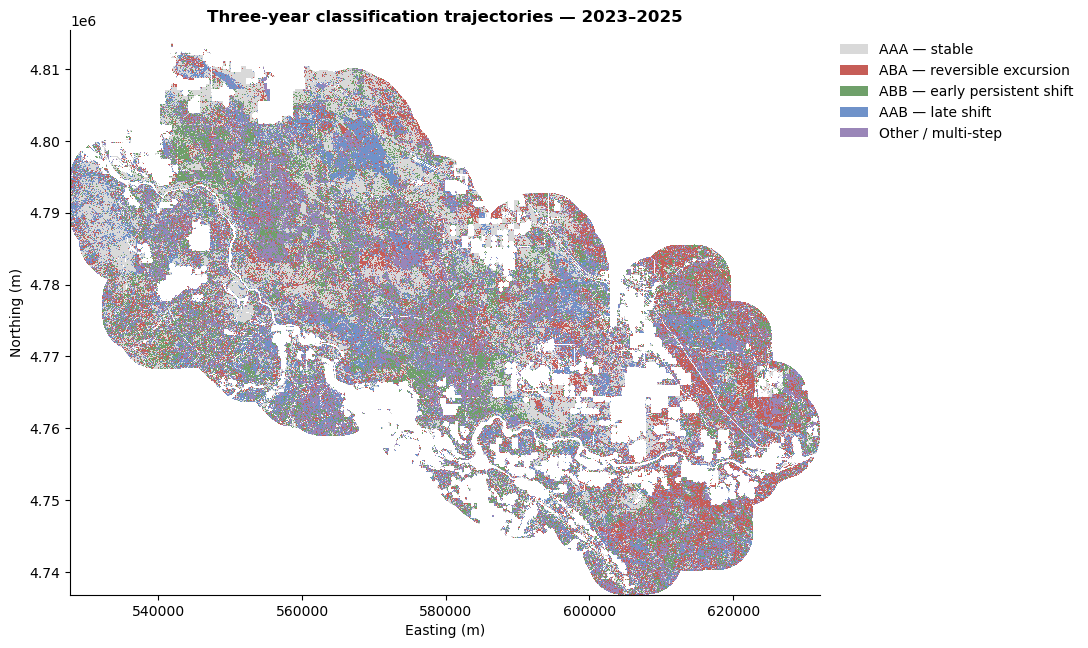

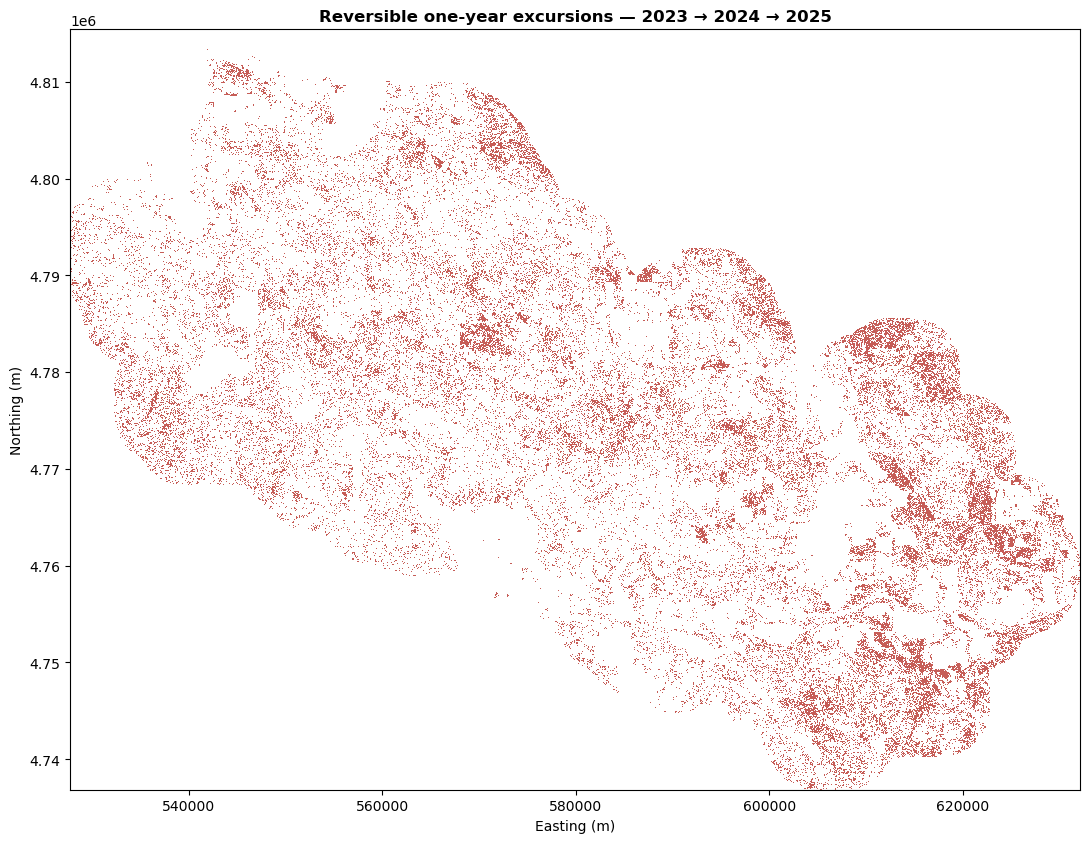


THREE-YEAR TRAJECTORY FRACTIONS


,,trajectory_type,AAA_stable,AAB_late_shift,ABA_reversible,ABB_early_persistent_shift,ABC_or_other
year0,year1,year2,,,,,
2016,2017,2018,0.2653,0.1699,0.1832,0.1529,0.2288
2017,2018,2019,0.2614,0.1568,0.1465,0.2017,0.2335
2018,2019,2020,0.2971,0.1661,0.1554,0.1781,0.2033
2019,2020,2021,0.3154,0.1598,0.1279,0.2026,0.1943
2020,2021,2022,0.3102,0.2078,0.1351,0.1610,0.1859
2021,2022,2023,0.3053,0.1659,0.1724,0.1642,0.1922
2022,2023,2024,0.2498,0.2198,0.1374,0.1472,0.2458
2023,2024,2025,0.2464,0.1506,0.1764,0.1761,0.2505



REVERSIBLE EXCURSION PROBABILITY BY ORIGIN CLASS


,,parent,P1,P2,P3,P4,P5,P6,P7,P8
year0,year1,year2,,,,,,,,
2016,2017,2018,0.0860,0.2362,0.1623,0.2380,0.2738,0.1465,0.1217,0.0870
2017,2018,2019,0.1770,0.1147,0.2348,0.1178,0.1235,0.1063,0.1449,0.0765
2018,2019,2020,0.1086,0.1437,0.2093,0.1655,0.1159,0.1666,0.2133,0.1513
2019,2020,2021,0.2265,0.1487,0.0806,0.1121,0.1317,0.0810,0.1355,0.0853
2020,2021,2022,0.0715,0.0688,0.1821,0.1545,0.1597,0.1527,0.0457,0.0955
2021,2022,2023,0.0724,0.2918,0.1583,0.1900,0.1677,0.2545,0.2960,0.1078
2022,2023,2024,0.1683,0.0880,0.1067,0.1059,0.2637,0.1011,0.1640,0.0559
2023,2024,2025,0.0980,0.1852,0.1737,0.2179,0.0726,0.2886,0.1231,0.2256



P2 → P1 → P2 REVERSALS


,year0,year1,year2,path,n_pixels,probability_given_P2_origin
0,2016,2017,2018,P2→P1→P2,175064,0.12192
1,2017,2018,2019,P2→P1→P2,27585,0.01257
2,2018,2019,2020,P2→P1→P2,143205,0.05278
3,2019,2020,2021,P2→P1→P2,21402,0.00696
4,2020,2021,2022,P2→P1→P2,101594,0.03924
5,2021,2022,2023,P2→P1→P2,253629,0.10828
6,2022,2023,2024,P2→P1→P2,15248,0.01140
7,2023,2024,2025,P2→P1→P2,251464,0.07911



TOP REVERSIBLE PATHS PER THREE-YEAR WINDOW


,year0,year1,year2,path,n_pixels,probability_given_origin,fraction_of_origin_reversals
25,2016,2017,2018,P4→P6→P4,630265,0.0687,0.2884
21,2016,2017,2018,P4→P1→P4,604534,0.0658,0.2766
30,2016,2017,2018,P5→P3→P5,597299,0.1138,0.4156
24,2016,2017,2018,P4→P5→P4,332682,0.0362,0.1522
17,2016,2017,2018,P3→P5→P3,300566,0.0419,0.2579
...,...,...,...,...,...,...,...
399,2023,2024,2025,P2→P1→P2,251464,0.0791,0.4271
409,2023,2024,2025,P3→P5→P3,241329,0.0413,0.2376
430,2023,2024,2025,P6→P4→P6,173078,0.0506,0.1754
419,2023,2024,2025,P4→P8→P4,167675,0.0152,0.0697



Three-year trajectory analysis complete.


In [21]:
# =============================================================================
# 18. THREE-YEAR TRAJECTORY DIAGNOSTIC
#
# AAA = stable across all 3 years
# ABA = reversible one-year excursion
# ABB = early shift that persists into year 3
# AAB = late shift appearing only in year 3
# OTHER = more complex / multi-step trajectory
# =============================================================================


# =============================================================================
# SETTINGS
# =============================================================================

SAVE_THREE_YEAR_MAPS = True
SHOW_THREE_YEAR_MAPS = True

# Highlight this specific ecological hypothesis separately:
# Non-ARTR shrub -> BRTE/shrub mix -> Non-ARTR shrub
FOCAL_REVERSAL = (
    2,
    1,
    2,
)


# =============================================================================
# STORAGE
# =============================================================================

trajectory_summary_records = []
reversal_path_records = []
class_reversal_records = []
focal_reversal_records = []


# =============================================================================
# HELPER
# =============================================================================

def read_classification(
    year,
):

    path = classified_path(
        year
    )

    with rasterio.open(
        path
    ) as src:

        arr = src.read(
            1,
            masked=False,
        )

        bounds = src.bounds

    return (
        arr,
        bounds,
    )


# =============================================================================
# LOOP THROUGH CONSECUTIVE 3-YEAR WINDOWS
# =============================================================================

for year0, year1, year2 in zip(
    YEARS_TO_MAP[:-2],
    YEARS_TO_MAP[1:-1],
    YEARS_TO_MAP[2:],
):

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"THREE-YEAR TRAJECTORY: "
        f"{year0} → {year1} → {year2}"
    )

    print(
        "=" * 100
    )


    # -------------------------------------------------------------------------
    # LOAD THREE ANNUAL CLASSIFICATIONS
    # -------------------------------------------------------------------------

    state0, bounds = read_classification(
        year0
    )

    state1, _ = read_classification(
        year1
    )

    state2, _ = read_classification(
        year2
    )


    # -------------------------------------------------------------------------
    # VALID THREE-YEAR PIXELS
    # -------------------------------------------------------------------------

    valid = (
        np.isin(
            state0,
            VEG_PARENT_CODES,
        )
        & np.isin(
            state1,
            VEG_PARENT_CODES,
        )
        & np.isin(
            state2,
            VEG_PARENT_CODES,
        )
    )

    A = state0[
        valid
    ]

    B = state1[
        valid
    ]

    C = state2[
        valid
    ]

    n_valid = len(
        A
    )


    # -------------------------------------------------------------------------
    # TRAJECTORY TYPES
    # -------------------------------------------------------------------------

    stable = (
        (A == B)
        & (B == C)
    )

    reversible = (
        (A != B)
        & (A == C)
    )

    early_shift = (
        (A != B)
        & (B == C)
    )

    late_shift = (
        (A == B)
        & (B != C)
    )

    other = ~(
        stable
        | reversible
        | early_shift
        | late_shift
    )


    categories = {
        "AAA_stable": stable,
        "ABA_reversible": reversible,
        "ABB_early_persistent_shift": early_shift,
        "AAB_late_shift": late_shift,
        "ABC_or_other": other,
    }


    for name, mask in categories.items():

        n = int(
            mask.sum()
        )

        trajectory_summary_records.append(
            {
                "year0": year0,
                "year1": year1,
                "year2": year2,
                "trajectory_type": name,
                "n_pixels": n,
                "fraction": (
                    n
                    / n_valid
                    if n_valid > 0
                    else np.nan
                ),
            }
        )


    # -------------------------------------------------------------------------
    # CLASS-SPECIFIC REVERSAL RATE
    #
    # P(A -> anything-but-A -> A | A at t0)
    # -------------------------------------------------------------------------

    for parent in VEG_PARENT_CODES:

        origin = (
            A
            == parent
        )

        n_origin = int(
            origin.sum()
        )

        parent_reversal = (
            origin
            & reversible
        )

        n_parent_reversal = int(
            parent_reversal.sum()
        )

        class_reversal_records.append(
            {
                "year0": year0,
                "year1": year1,
                "year2": year2,
                "parent": parent,
                "parent_label": PARENT_LABELS[
                    parent
                ],
                "n_origin_pixels": n_origin,
                "n_reversible_pixels": n_parent_reversal,
                "reversal_probability": (
                    n_parent_reversal
                    / n_origin
                    if n_origin > 0
                    else np.nan
                ),
            }
        )


    # -------------------------------------------------------------------------
    # INDIVIDUAL ABA PATHWAYS
    #
    # Example:
    # P2 -> P1 -> P2
    # -------------------------------------------------------------------------

    reversible_A = A[
        reversible
    ]

    reversible_B = B[
        reversible
    ]

    reversible_C = C[
        reversible
    ]

    # Since A == C for reversible pixels, encode A/B pair.
    path_index = (
        (
            reversible_A.astype(
                np.int16
            )
            - 1
        )
        * 8
        + (
            reversible_B.astype(
                np.int16
            )
            - 1
        )
    )

    path_counts = np.bincount(
        path_index,
        minlength=64,
    ).reshape(
        8,
        8,
    )


    for i, origin_parent in enumerate(
        VEG_PARENT_CODES
    ):

        origin_total = int(
            (
                A
                == origin_parent
            ).sum()
        )

        reversal_total = int(
            path_counts[
                i,
                :
            ].sum()
        )

        for j, excursion_parent in enumerate(
            VEG_PARENT_CODES
        ):

            if origin_parent == excursion_parent:
                continue

            n_path = int(
                path_counts[
                    i,
                    j
                ]
            )

            reversal_path_records.append(
                {
                    "year0": year0,
                    "year1": year1,
                    "year2": year2,
                    "origin_parent": origin_parent,
                    "excursion_parent": excursion_parent,
                    "return_parent": origin_parent,
                    "path": (
                        f"P{origin_parent}"
                        f"→P{excursion_parent}"
                        f"→P{origin_parent}"
                    ),
                    "n_pixels": n_path,

                    # Fraction of all pixels beginning in parent A
                    "probability_given_origin": (
                        n_path
                        / origin_total
                        if origin_total > 0
                        else np.nan
                    ),

                    # Composition of all reversible excursions from parent A
                    "fraction_of_origin_reversals": (
                        n_path
                        / reversal_total
                        if reversal_total > 0
                        else np.nan
                    ),
                }
            )


    # -------------------------------------------------------------------------
    # FOCAL P2 -> P1 -> P2 REVERSAL
    # -------------------------------------------------------------------------

    focal_a, focal_b, focal_c = FOCAL_REVERSAL

    focal = (
        (A == focal_a)
        & (B == focal_b)
        & (C == focal_c)
    )

    n_focal = int(
        focal.sum()
    )

    n_focal_origin = int(
        (
            A
            == focal_a
        ).sum()
    )

    focal_reversal_records.append(
        {
            "year0": year0,
            "year1": year1,
            "year2": year2,
            "path": (
                f"P{focal_a}"
                f"→P{focal_b}"
                f"→P{focal_c}"
            ),
            "n_pixels": n_focal,
            "probability_given_P2_origin": (
                n_focal
                / n_focal_origin
                if n_focal_origin > 0
                else np.nan
            ),
        }
    )


    # -------------------------------------------------------------------------
    # REBUILD FULL-SIZE TRAJECTORY MAP
    #
    # 0 = invalid
    # 1 = AAA stable
    # 2 = ABA reversible
    # 3 = ABB early persistent shift
    # 4 = AAB late shift
    # 5 = other
    # -------------------------------------------------------------------------

    trajectory_map = np.zeros_like(
        state0,
        dtype=np.uint8,
    )

    trajectory_valid = np.zeros(
        n_valid,
        dtype=np.uint8,
    )

    trajectory_valid[
        stable
    ] = 1

    trajectory_valid[
        reversible
    ] = 2

    trajectory_valid[
        early_shift
    ] = 3

    trajectory_valid[
        late_shift
    ] = 4

    trajectory_valid[
        other
    ] = 5

    trajectory_map[
        valid
    ] = trajectory_valid


    # -------------------------------------------------------------------------
    # PLOT TRAJECTORY-TYPE MAP
    # -------------------------------------------------------------------------

    if SHOW_THREE_YEAR_MAPS:

        trajectory_cmap = ListedColormap(
            [
                "#D9D9D9",  # stable
                "#C65D57",  # reversible
                "#6FA06A",  # early persistent shift
                "#6F92C9",  # late shift
                "#9A86B8",  # complex
            ]
        )

        trajectory_norm = BoundaryNorm(
            np.arange(
                0.5,
                6.5,
                1,
            ),
            trajectory_cmap.N,
        )

        plot_arr = np.ma.masked_where(
            trajectory_map
            == 0,
            trajectory_map,
        )

        fig, ax = plt.subplots(
            figsize=(
                11,
                9,
            )
        )

        ax.imshow(
            plot_arr,
            cmap=trajectory_cmap,
            norm=trajectory_norm,
            extent=[
                bounds.left,
                bounds.right,
                bounds.bottom,
                bounds.top,
            ],
            interpolation="nearest",
        )

        ax.set_title(
            (
                f"Three-year classification trajectories — "
                f"{year0}–{year2}"
            ),
            fontweight="bold",
        )

        ax.set_xlabel(
            "Easting (m)"
        )

        ax.set_ylabel(
            "Northing (m)"
        )

        trajectory_legend = [
            Patch(
                facecolor="#D9D9D9",
                label="AAA — stable",
            ),
            Patch(
                facecolor="#C65D57",
                label="ABA — reversible excursion",
            ),
            Patch(
                facecolor="#6FA06A",
                label="ABB — early persistent shift",
            ),
            Patch(
                facecolor="#6F92C9",
                label="AAB — late shift",
            ),
            Patch(
                facecolor="#9A86B8",
                label="Other / multi-step",
            ),
        ]

        ax.legend(
            handles=trajectory_legend,
            loc="upper left",
            bbox_to_anchor=(
                1.01,
                1.0,
            ),
            frameon=False,
        )

        ax.spines[
            "top"
        ].set_visible(
            False
        )

        ax.spines[
            "right"
        ].set_visible(
            False
        )

        fig.tight_layout()


        if SAVE_THREE_YEAR_MAPS:

            fig.savefig(
                OUTPUT_DIR
                / (
                    f"AnnualZScore_threeYearTrajectory_"
                    f"{year0}_{year1}_{year2}.png"
                ),
                dpi=300,
                bbox_inches="tight",
            )


        plt.show()

        plt.close(
            fig
        )


    # -------------------------------------------------------------------------
    # SPECIAL MAP: REVERSIBLE PIXELS ONLY
    # -------------------------------------------------------------------------

    reversible_full = np.zeros_like(
        state0,
        dtype=np.uint8,
    )

    reversible_full[
        valid
    ] = reversible.astype(
        np.uint8
    )

    reversible_plot = np.ma.masked_where(
        reversible_full
        == 0,
        reversible_full,
    )


    if SHOW_THREE_YEAR_MAPS:

        fig, ax = plt.subplots(
            figsize=(
                11,
                9,
            )
        )

        ax.imshow(
            reversible_plot,
            cmap=ListedColormap(
                [
                    "#C65D57",
                ]
            ),
            extent=[
                bounds.left,
                bounds.right,
                bounds.bottom,
                bounds.top,
            ],
            interpolation="nearest",
        )

        ax.set_title(
            (
                f"Reversible one-year excursions — "
                f"{year0} → {year1} → {year2}"
            ),
            fontweight="bold",
        )

        ax.set_xlabel(
            "Easting (m)"
        )

        ax.set_ylabel(
            "Northing (m)"
        )

        fig.tight_layout()


        if SAVE_THREE_YEAR_MAPS:

            fig.savefig(
                OUTPUT_DIR
                / (
                    f"AnnualZScore_reversiblePixels_"
                    f"{year0}_{year1}_{year2}.png"
                ),
                dpi=300,
                bbox_inches="tight",
            )


        plt.show()

        plt.close(
            fig
        )


    del state0
    del state1
    del state2
    del A
    del B
    del C


# =============================================================================
# SAVE TABLES
# =============================================================================

trajectory_summary_df = pd.DataFrame(
    trajectory_summary_records
)

reversal_paths_df = pd.DataFrame(
    reversal_path_records
)

class_reversal_df = pd.DataFrame(
    class_reversal_records
)

focal_reversal_df = pd.DataFrame(
    focal_reversal_records
)


trajectory_summary_df.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_threeYear_trajectory_summary.csv",
    index=False,
)

reversal_paths_df.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_threeYear_reversible_paths.csv",
    index=False,
)

class_reversal_df.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_threeYear_class_reversal_rates.csv",
    index=False,
)

focal_reversal_df.to_csv(
    OUTPUT_DIR
    / "AnnualZScore_P2_P1_P2_reversal_summary.csv",
    index=False,
)


# =============================================================================
# COMPACT TRAJECTORY SUMMARY
# =============================================================================

trajectory_fraction_table = (
    trajectory_summary_df
    .pivot(
        index=[
            "year0",
            "year1",
            "year2",
        ],
        columns="trajectory_type",
        values="fraction",
    )
)

print(
    "\nTHREE-YEAR TRAJECTORY FRACTIONS"
)

display(
    trajectory_fraction_table.round(
        4
    )
)


# =============================================================================
# CLASS-SPECIFIC REVERSAL RATE
# =============================================================================

class_reversal_table = (
    class_reversal_df
    .pivot(
        index=[
            "year0",
            "year1",
            "year2",
        ],
        columns="parent",
        values="reversal_probability",
    )
    .rename(
        columns={
            i: f"P{i}"
            for i in VEG_PARENT_CODES
        }
    )
)

print(
    "\nREVERSIBLE EXCURSION PROBABILITY BY ORIGIN CLASS"
)

display(
    class_reversal_table.round(
        4
    )
)


# =============================================================================
# FOCAL P2 -> P1 -> P2 RESULT
# =============================================================================

print(
    "\nP2 → P1 → P2 REVERSALS"
)

display(
    focal_reversal_df.round(
        5
    )
)


# =============================================================================
# TOP REVERSIBLE PATHWAYS FOR EACH THREE-YEAR WINDOW
# =============================================================================

top_reversals = (
    reversal_paths_df
    .sort_values(
        [
            "year0",
            "n_pixels",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        [
            "year0",
            "year1",
            "year2",
        ],
        as_index=False,
    )
    .head(
        10
    )
)

print(
    "\nTOP REVERSIBLE PATHS PER THREE-YEAR WINDOW"
)

display(
    top_reversals[
        [
            "year0",
            "year1",
            "year2",
            "path",
            "n_pixels",
            "probability_given_origin",
            "fraction_of_origin_reversals",
        ]
    ].round(
        4
    )
)


print(
    "\nThree-year trajectory analysis complete."
)

## Interpretation boundary

This notebook tests one specific hypothesis:

> Does expressing every IA45 feature relative to its own annual landscape distribution improve temporal transfer of vegetation-state classification?

The key comparison against the raw baseline is:

- grouped OOF accuracy / macro F1;
- leave-one-year-out accuracy / macro F1;
- annual mapped class proportions;
- annual uncertainty;
- spatial persistence of ecologically slow-turnover classes.

An improvement in LOYO after normalization would support the hypothesis that part of the original cross-year failure arose from annual displacement of the optical coordinate system.

It would **not**, by itself, prove that all annual variation is nuisance variation. Known ecological transitions and disturbance responses still need to remain visible.
